In [3]:
import sys
import torch
import librosa
import numpy as np
import pandas as pd

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Librosa:", librosa.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu130
Librosa: 0.11.0
NumPy: 2.1.3
Pandas: 2.2.3


In [4]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [5]:
!pip install -q librosa soundfile pandas scikit-learn matplotlib seaborn tqdm

In [6]:
import torch
import librosa
import pandas
import sklearn
import matplotlib
import seaborn
import soundfile
import tqdm

print("All dependencies imported successfully.")

All dependencies imported successfully.


In [7]:
!git clone https://github.com/karolpiczak/ESC-50.git

Cloning into 'ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 17.64 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


In [8]:
from pathlib import Path

ESC50_DIR = Path("/content/ESC-50")

print(ESC50_DIR.exists())

True


In [9]:
import os

print(os.listdir(ESC50_DIR))

['.git', 'esc50.gif', 'pytest.ini', '.circleci', 'README.md', 'tests', 'audio', 'meta', '.gitignore', 'LICENSE', '.github', 'requirements.txt']


In [10]:
AUDIO_DIR = ESC50_DIR / "audio"
META_DIR = ESC50_DIR / "meta"

print("Audio directory:", AUDIO_DIR)
print("Metadata directory:", META_DIR)

Audio directory: /content/ESC-50/audio
Metadata directory: /content/ESC-50/meta


In [11]:
import pandas as pd

metadata_path = META_DIR / "esc50.csv"

df = pd.read_csv(metadata_path)

df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [12]:
print("Number of recordings:", len(df))
print("Number of classes:", df["category"].nunique())
print("Number of folds:", df["fold"].nunique())

Number of recordings: 2000
Number of classes: 50
Number of folds: 5


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2000 non-null   object
 1   fold      2000 non-null   int64 
 2   target    2000 non-null   int64 
 3   category  2000 non-null   object
 4   esc10     2000 non-null   bool  
 5   src_file  2000 non-null   int64 
 6   take      2000 non-null   object
dtypes: bool(1), int64(3), object(3)
memory usage: 95.8+ KB


In [14]:
df.columns

Index(['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take'], dtype='object')

In [15]:
df["category"].value_counts().sort_index()

,count
category,
airplane,40
breathing,40
brushing_teeth,40
can_opening,40
car_horn,40
cat,40
chainsaw,40
chirping_birds,40
church_bells,40


In [16]:
df["fold"].value_counts().sort_index()

,count
fold,
1,400
2,400
3,400
4,400
5,400


In [17]:
audio_files = list(AUDIO_DIR.glob("*.wav"))

print("WAV files found:", len(audio_files))

WAV files found: 2000


In [18]:
metadata_files = set(df["filename"])
actual_files = {file.name for file in audio_files}

missing_files = metadata_files - actual_files
extra_files = actual_files - metadata_files

print("Missing files:", len(missing_files))
print("Extra files:", len(extra_files))

Missing files: 0
Extra files: 0


In [19]:
import librosa

sample_filename = df.iloc[0]["filename"]
sample_path = AUDIO_DIR / sample_filename

audio, sample_rate = librosa.load(
    sample_path,
    sr=None,
    mono=True
)

print("File:", sample_filename)
print("Sample rate:", sample_rate)
print("Number of samples:", len(audio))
print("Duration:", len(audio) / sample_rate, "seconds")

File: 1-100032-A-0.wav
Sample rate: 44100
Number of samples: 220500
Duration: 5.0 seconds


In [20]:
print("Number of recordings:", len(df))
print("Number of classes:", df["category"].nunique())
print("Number of folds:", df["fold"].nunique())
print("WAV files found:", len(audio_files))
print("Missing files:", len(missing_files))
print("Extra files:", len(extra_files))

Number of recordings: 2000
Number of classes: 50
Number of folds: 5
WAV files found: 2000
Missing files: 0
Extra files: 0


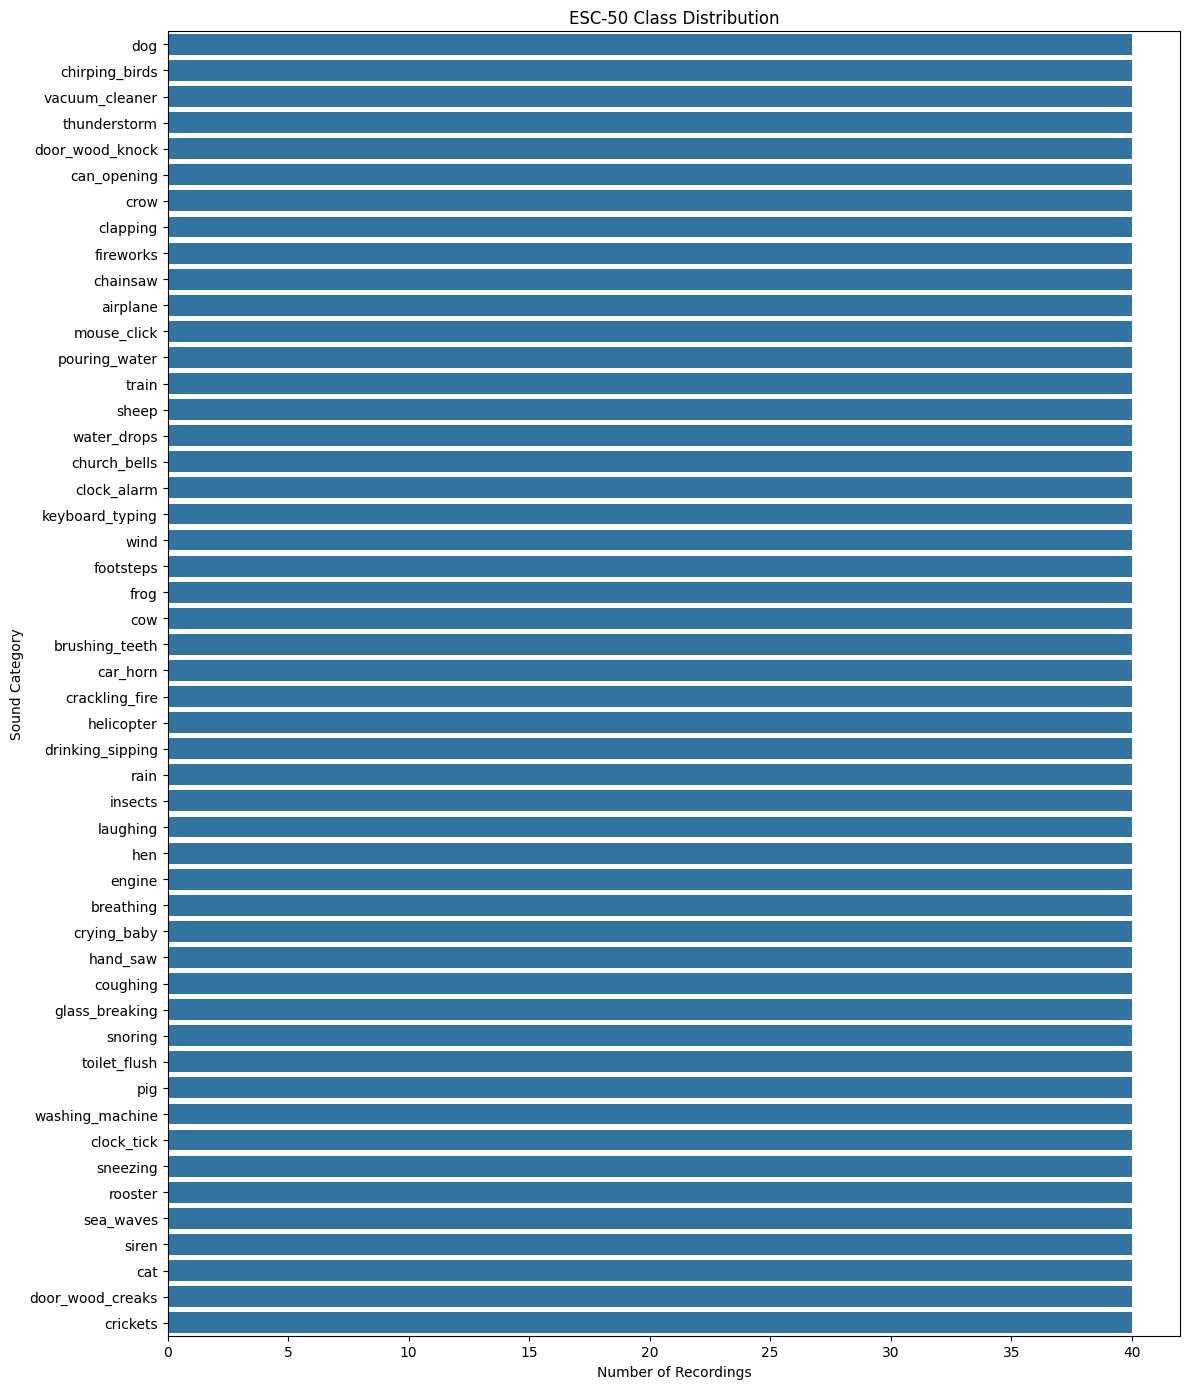

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = df["category"].value_counts().sort_values()

plt.figure(figsize=(12, 14))

sns.barplot(
    x=class_counts.values,
    y=class_counts.index
)

plt.title("ESC-50 Class Distribution")
plt.xlabel("Number of Recordings")
plt.ylabel("Sound Category")
plt.tight_layout()
plt.show()

In [22]:
sample_rates = []
durations = []

for filename in df["filename"]:
    audio_path = AUDIO_DIR / filename

    audio, sr = librosa.load(
        audio_path,
        sr=None,
        mono=True
    )

    sample_rates.append(sr)
    durations.append(len(audio) / sr)

print("Unique sample rates:", sorted(set(sample_rates)))
print(
    f"Duration range: "
    f"{min(durations):.2f} - {max(durations):.2f} seconds"
)

Unique sample rates: [44100]
Duration range: 5.00 - 5.00 seconds


In [23]:
sample_categories = [
    "dog",
    "rain",
    "clock_tick",
    "chainsaw"
]

representative_samples = (
    df[df["category"].isin(sample_categories)]
    .groupby("category", group_keys=False)
    .apply(lambda x: x.sample(1, random_state=42))
    .reset_index(drop=True)
)

representative_samples[["filename", "category", "fold"]]

/tmp/ipykernel_2255/527914938.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1, random_state=42))


,filename,category,fold
0,3-118658-A-41.wav,chainsaw,3
1,3-164688-A-38.wav,clock_tick,3
2,3-157695-A-0.wav,dog,3
3,3-142006-A-10.wav,rain,3


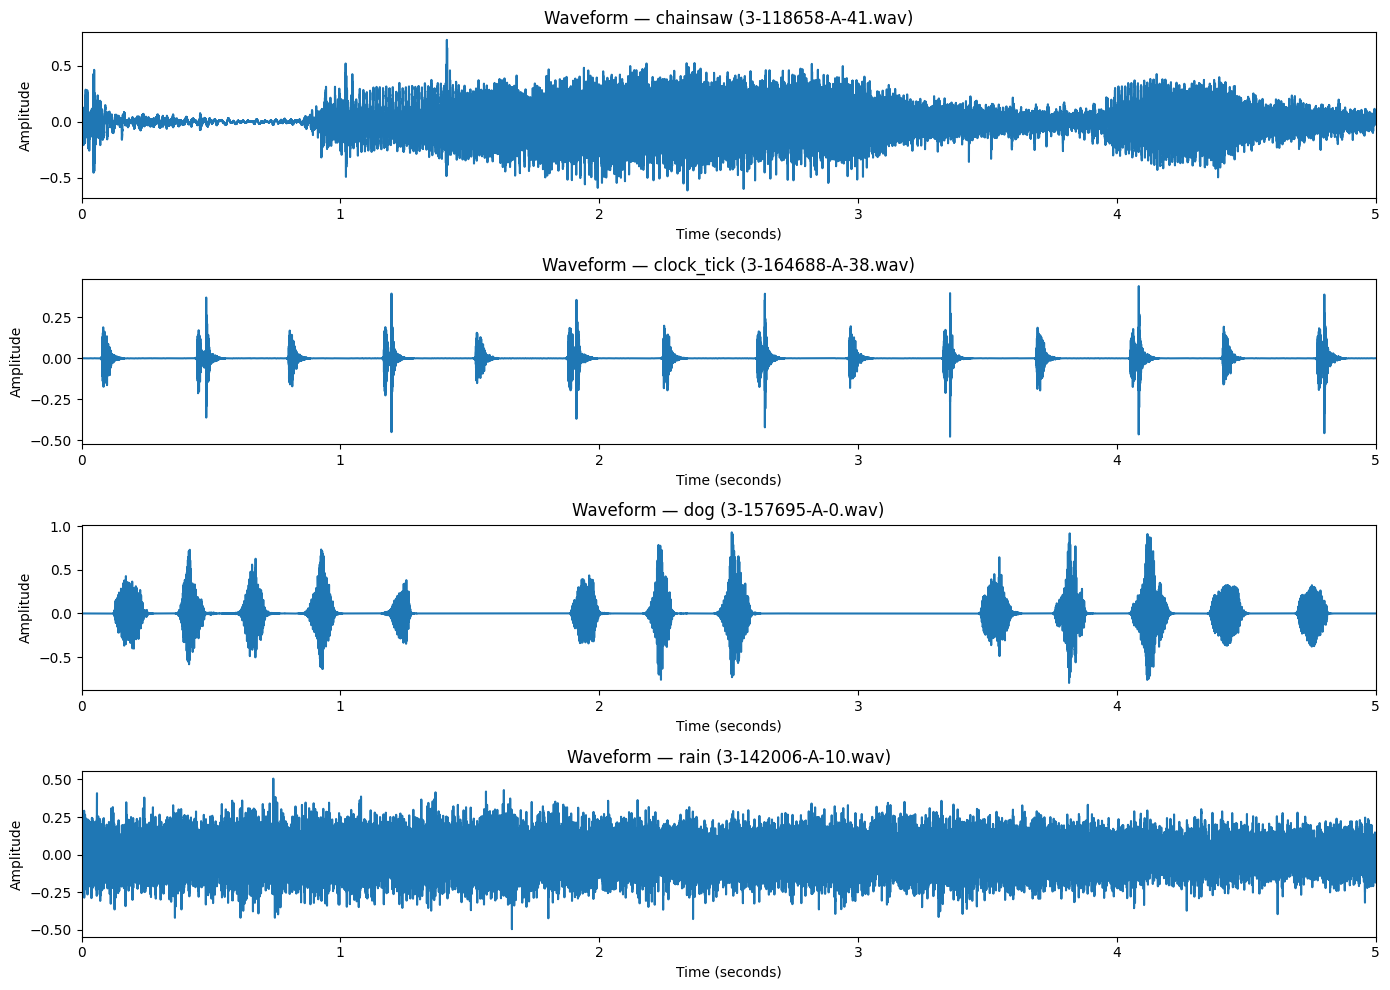

In [24]:
fig, axes = plt.subplots(
    len(representative_samples),
    1,
    figsize=(14, 10)
)

for ax, (_, row) in zip(
    axes,
    representative_samples.iterrows()
):
    audio_path = AUDIO_DIR / row["filename"]

    audio, sr = librosa.load(
        audio_path,
        sr=None,
        mono=True
    )

    time = np.arange(len(audio)) / sr

    ax.plot(time, audio)

    ax.set_title(
        f"Waveform — {row['category']} ({row['filename']})"
    )
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, len(audio) / sr)

plt.tight_layout()
plt.show()

In [25]:
from IPython.display import Audio, display

for _, row in representative_samples.iterrows():

    audio_path = AUDIO_DIR / row["filename"]

    print(f"Category: {row['category']}")
    print(f"File: {row['filename']}")

    display(Audio(
        filename=str(audio_path)
    ))

    print()

Category: chainsaw
File: 3-118658-A-41.wav



Category: clock_tick
File: 3-164688-A-38.wav



Category: dog
File: 3-157695-A-0.wav



Category: rain
File: 3-142006-A-10.wav


In [26]:
example_row = representative_samples.iloc[0]

example_path = AUDIO_DIR / example_row["filename"]

example_audio, example_sr = librosa.load(
    example_path,
    sr=None,
    mono=True
)

print("Category:", example_row["category"])
print("Filename:", example_row["filename"])
print("Sample rate:", example_sr)
print("Samples:", len(example_audio))
print("Duration:", len(example_audio) / example_sr)

Category: chainsaw
Filename: 3-118658-A-41.wav
Sample rate: 44100
Samples: 220500
Duration: 5.0


In [27]:
# ============================================================
# AUDIO PREPROCESSING CONFIGURATION
# ============================================================

SAMPLE_RATE = 22050
DURATION = 5

N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

FMIN = 0
FMAX = SAMPLE_RATE // 2

TOP_DB = 80

print("Sample rate:", SAMPLE_RATE)
print("Duration:", DURATION, "seconds")
print("Mel bands:", N_MELS)
print("FFT size:", N_FFT)
print("Hop length:", HOP_LENGTH)
print("Minimum frequency:", FMIN, "Hz")
print("Maximum frequency:", FMAX, "Hz")
print("dB range:", TOP_DB, "dB")

Sample rate: 22050
Duration: 5 seconds
Mel bands: 128
FFT size: 2048
Hop length: 512
Minimum frequency: 0 Hz
Maximum frequency: 11025 Hz
dB range: 80 dB


In [28]:
def preprocess_audio(audio_path):
    """
    Load and preprocess an ESC-50 audio recording.

    Returns:
        mel_normalized: NumPy array with shape
                        (N_MELS, time_frames)
                        normalized to [0, 1].
    """

    # --------------------------------------------------------
    # 1. Load audio
    # --------------------------------------------------------
    audio, _ = librosa.load(
        audio_path,
        sr=SAMPLE_RATE,
        mono=True
    )

    # --------------------------------------------------------
    # 2. Ensure exactly 5 seconds
    # --------------------------------------------------------
    target_length = SAMPLE_RATE * DURATION

    if len(audio) < target_length:
        # Zero-pad shorter recordings
        audio = np.pad(
            audio,
            (0, target_length - len(audio))
        )

    elif len(audio) > target_length:
        # Truncate longer recordings
        audio = audio[:target_length]

    # --------------------------------------------------------
    # 3. Compute Mel Spectrogram
    # --------------------------------------------------------
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    # --------------------------------------------------------
    # 4. Convert power to decibels
    # --------------------------------------------------------
    mel_db = librosa.power_to_db(
        mel,
        ref=np.max,
        top_db=TOP_DB
    )

    # --------------------------------------------------------
    # 5. Normalize from [-TOP_DB, 0] to [0, 1]
    # --------------------------------------------------------
    mel_normalized = (
        mel_db + TOP_DB
    ) / TOP_DB

    return mel_normalized.astype(np.float32)

In [29]:
processed_mel = preprocess_audio(example_path)

print("Mel Spectrogram shape:", processed_mel.shape)
print("Data type:", processed_mel.dtype)
print("Minimum value:", processed_mel.min())
print("Maximum value:", processed_mel.max())

Mel Spectrogram shape: (128, 216)
Data type: float32
Minimum value: 0.0
Maximum value: 1.0


In [30]:
for _, row in representative_samples.iterrows():

    path = AUDIO_DIR / row["filename"]

    mel = preprocess_audio(path)

    print(
        f"{row['category']:20s} → "
        f"shape={mel.shape}, "
        f"range=({mel.min():.2f}, {mel.max():.2f})"
    )

chainsaw             → shape=(128, 216), range=(0.00, 1.00)
clock_tick           → shape=(128, 216), range=(0.00, 1.00)
dog                  → shape=(128, 216), range=(0.00, 1.00)
rain                 → shape=(128, 216), range=(0.36, 1.00)


In [31]:
import librosa.display

In [32]:
def create_mel_spectrogram_for_display(audio_path):
    """
    Create a Mel Spectrogram in decibel scale for visualization.
    """

    audio, _ = librosa.load(
        audio_path,
        sr=SAMPLE_RATE,
        mono=True
    )

    target_length = SAMPLE_RATE * DURATION

    if len(audio) < target_length:
        audio = np.pad(
            audio,
            (0, target_length - len(audio))
        )

    elif len(audio) > target_length:
        audio = audio[:target_length]

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max,
        top_db=TOP_DB
    )

    return mel_db

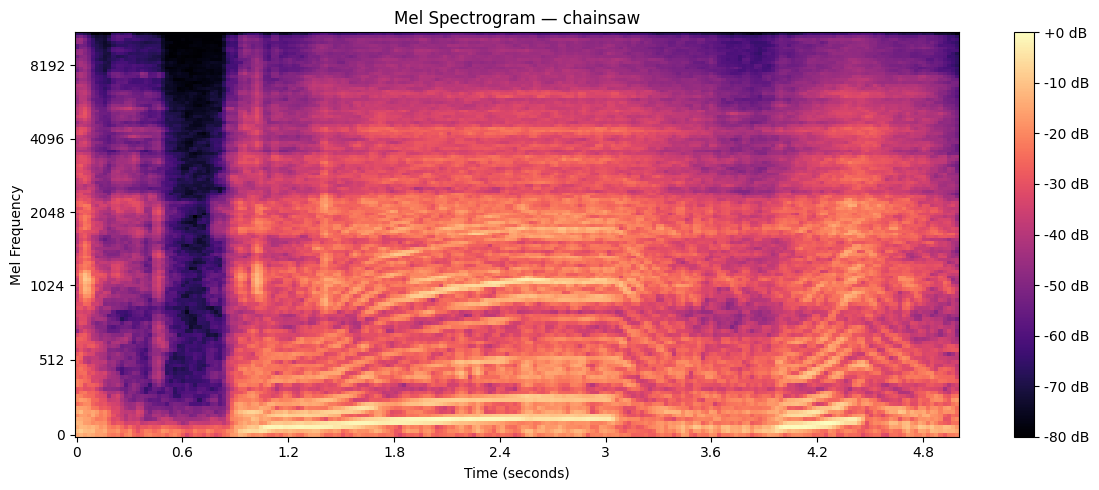

In [33]:
mel_db = create_mel_spectrogram_for_display(example_path)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_db,
    sr=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    fmax=FMAX
)

plt.colorbar(format="%+2.0f dB")
plt.title(
    f"Mel Spectrogram — {example_row['category']}"
)
plt.xlabel("Time (seconds)")
plt.ylabel("Mel Frequency")
plt.tight_layout()
plt.show()

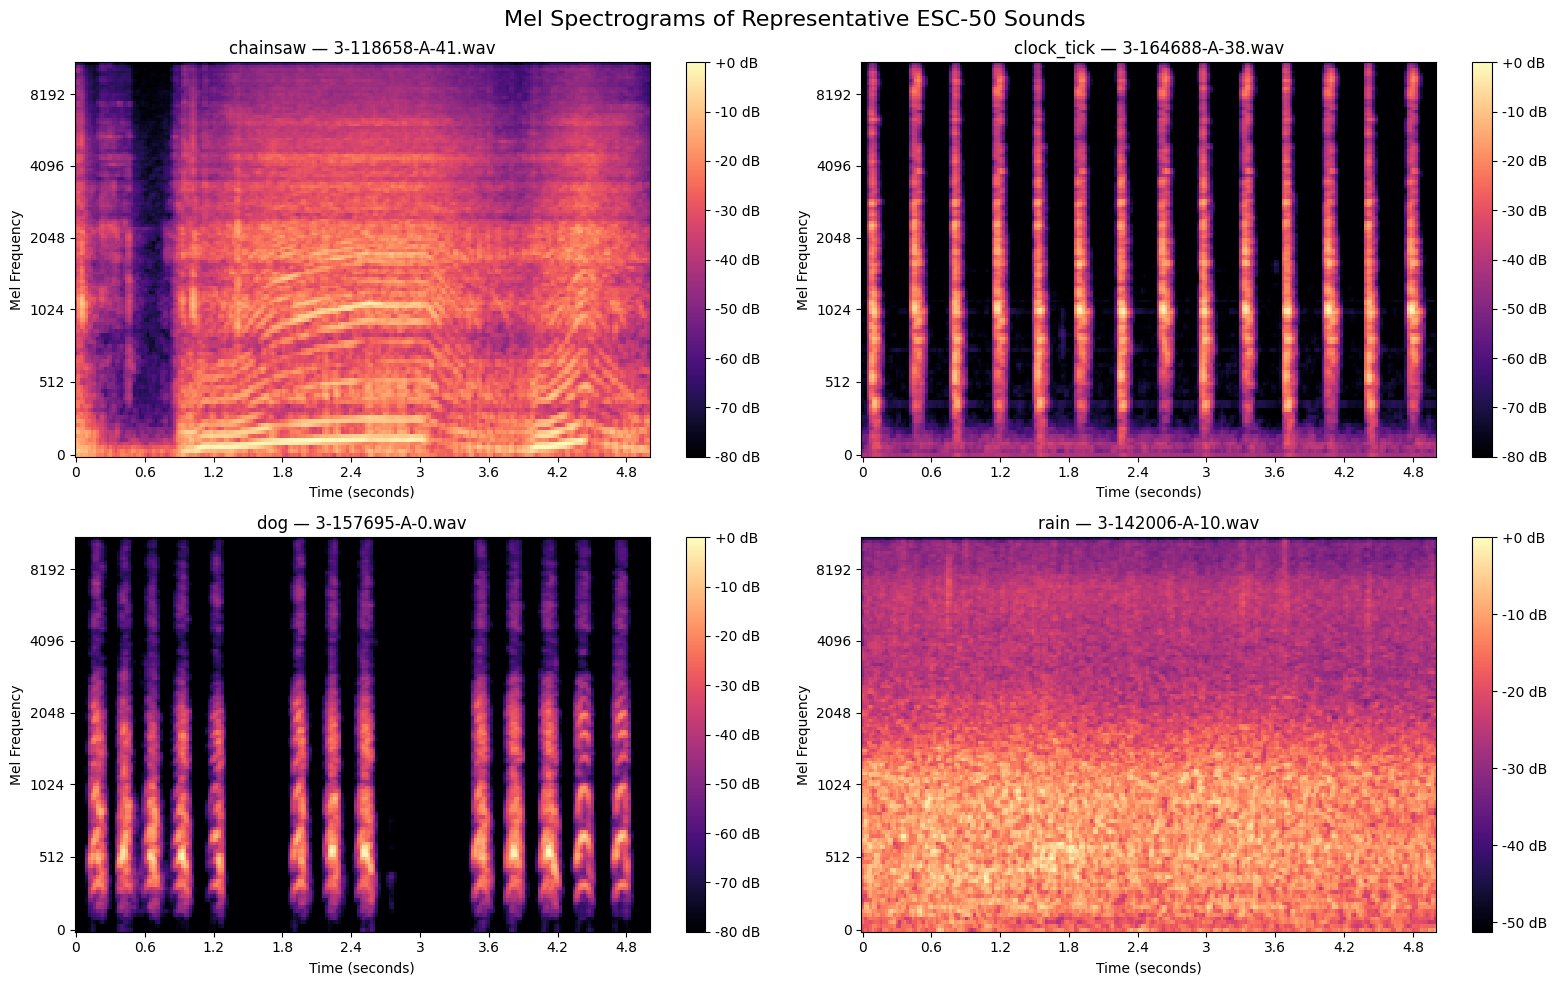

In [34]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10)
)

axes = axes.flatten()

for ax, (_, row) in zip(
    axes,
    representative_samples.iterrows()
):

    path = AUDIO_DIR / row["filename"]

    mel_db = create_mel_spectrogram_for_display(path)

    img = librosa.display.specshow(
        mel_db,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        fmax=FMAX,
        ax=ax
    )

    ax.set_title(
        f"{row['category']} — {row['filename']}"
    )
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Mel Frequency")

    fig.colorbar(
        img,
        ax=ax,
        format="%+2.0f dB"
    )

plt.suptitle(
    "Mel Spectrograms of Representative ESC-50 Sounds",
    fontsize=16
)

plt.tight_layout()
plt.show()

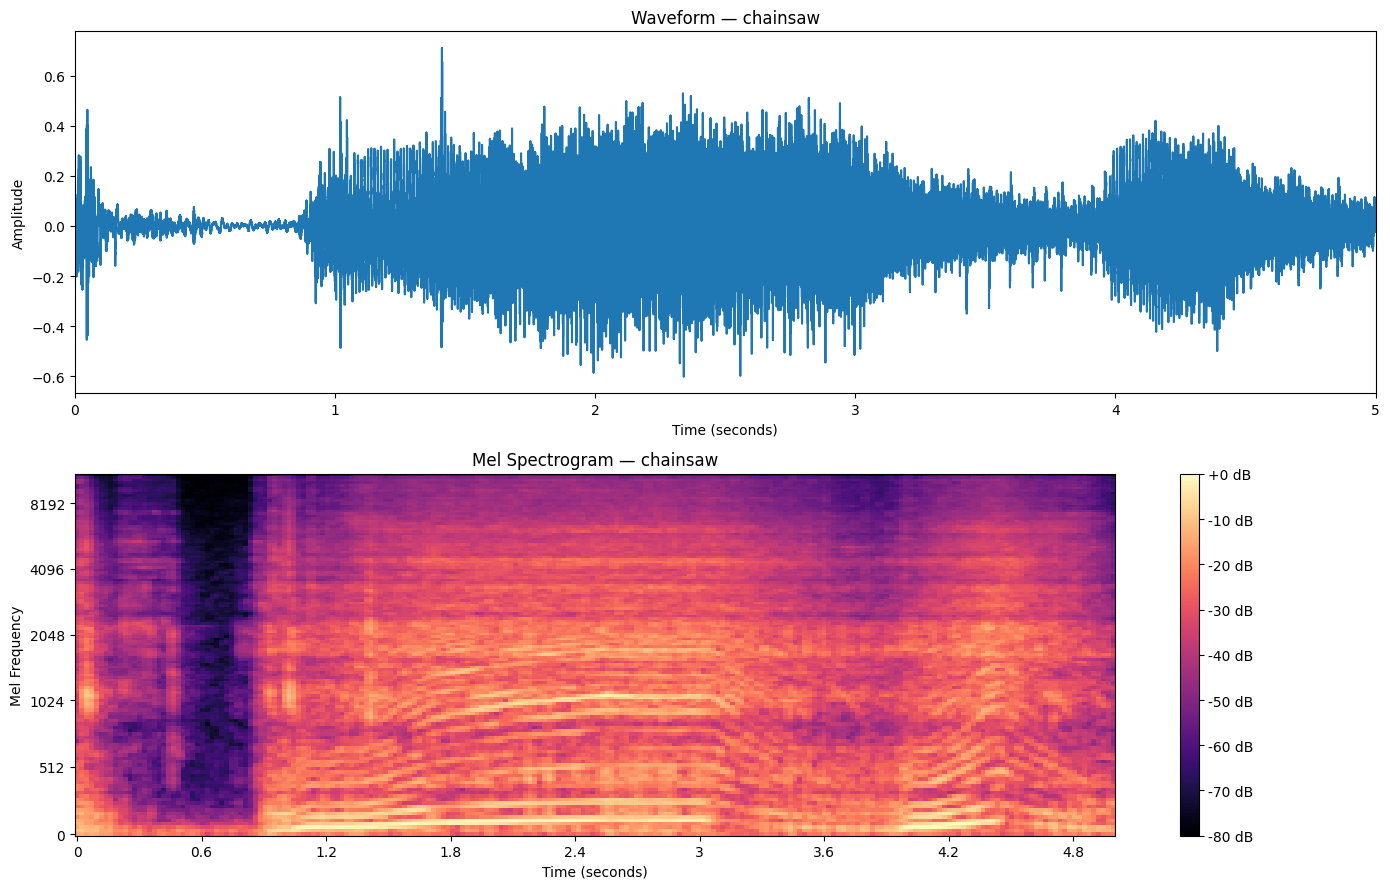

In [35]:
audio, sr = librosa.load(
    example_path,
    sr=SAMPLE_RATE,
    mono=True
)

target_length = SAMPLE_RATE * DURATION

if len(audio) < target_length:
    audio = np.pad(
        audio,
        (0, target_length - len(audio))
    )
elif len(audio) > target_length:
    audio = audio[:target_length]

mel_db = create_mel_spectrogram_for_display(example_path)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9)
)

# ------------------------------------------------------------
# Waveform
# ------------------------------------------------------------

time = np.arange(len(audio)) / SAMPLE_RATE

axes[0].plot(time, audio)

axes[0].set_title(
    f"Waveform — {example_row['category']}"
)
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim(0, DURATION)

# ------------------------------------------------------------
# Mel Spectrogram
# ------------------------------------------------------------

img = librosa.display.specshow(
    mel_db,
    sr=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    fmax=FMAX,
    ax=axes[1]
)

axes[1].set_title(
    f"Mel Spectrogram — {example_row['category']}"
)
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Mel Frequency")

fig.colorbar(
    img,
    ax=axes[1],
    format="%+2.0f dB"
)

plt.tight_layout()
plt.show()

In [37]:
import torch
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu130


In [38]:
class_names = sorted(df["category"].unique())

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

print("Number of classes:", len(class_names))
print("\nClass mapping:")

for index, class_name in enumerate(class_names):
    print(f"{index:2d} → {class_name}")

Number of classes: 50

Class mapping:
 0 → airplane
 1 → breathing
 2 → brushing_teeth
 3 → can_opening
 4 → car_horn
 5 → cat
 6 → chainsaw
 7 → chirping_birds
 8 → church_bells
 9 → clapping
10 → clock_alarm
11 → clock_tick
12 → coughing
13 → cow
14 → crackling_fire
15 → crickets
16 → crow
17 → crying_baby
18 → dog
19 → door_wood_creaks
20 → door_wood_knock
21 → drinking_sipping
22 → engine
23 → fireworks
24 → footsteps
25 → frog
26 → glass_breaking
27 → hand_saw
28 → helicopter
29 → hen
30 → insects
31 → keyboard_typing
32 → laughing
33 → mouse_click
34 → pig
35 → pouring_water
36 → rain
37 → rooster
38 → sea_waves
39 → sheep
40 → siren
41 → sneezing
42 → snoring
43 → thunderstorm
44 → toilet_flush
45 → train
46 → vacuum_cleaner
47 → washing_machine
48 → water_drops
49 → wind


In [39]:
class ESC50Dataset(Dataset):
    """
    PyTorch Dataset for ESC-50.

    Audio files are loaded and converted to normalized
    Mel Spectrograms on the fly.
    """

    def __init__(
        self,
        dataframe,
        audio_dir,
        class_to_idx
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        # ----------------------------------------------------
        # Get metadata
        # ----------------------------------------------------

        row = self.dataframe.iloc[index]

        audio_path = self.audio_dir / row["filename"]

        label = self.class_to_idx[row["category"]]

        # ----------------------------------------------------
        # Generate Mel Spectrogram
        # ----------------------------------------------------

        mel = preprocess_audio(audio_path)

        # ----------------------------------------------------
        # Convert NumPy → PyTorch tensor
        # ----------------------------------------------------

        mel_tensor = torch.tensor(
            mel,
            dtype=torch.float32
        )

        # ----------------------------------------------------
        # Add channel dimension
        #
        # (128, 216)
        #      ↓
        # (1, 128, 216)
        # ----------------------------------------------------

        mel_tensor = mel_tensor.unsqueeze(0)

        # ----------------------------------------------------
        # Convert label to tensor
        # ----------------------------------------------------

        label_tensor = torch.tensor(
            label,
            dtype=torch.long
        )

        return mel_tensor, label_tensor

In [40]:
dataset_test = ESC50Dataset(
    dataframe=df,
    audio_dir=AUDIO_DIR,
    class_to_idx=class_to_idx
)

print("Dataset size:", len(dataset_test))

Dataset size: 2000


In [41]:
mel_tensor, label_tensor = dataset_test[0]

print("Mel tensor shape:", mel_tensor.shape)
print("Mel tensor dtype:", mel_tensor.dtype)
print("Label:", label_tensor.item())
print("Class:", idx_to_class[label_tensor.item()])

Mel tensor shape: torch.Size([1, 128, 216])
Mel tensor dtype: torch.float32
Label: 18
Class: dog


In [42]:
print("Minimum:", mel_tensor.min().item())
print("Maximum:", mel_tensor.max().item())

Minimum: 0.0
Maximum: 1.0


In [43]:
row = df.iloc[0]

print("Metadata:")
print("Filename:", row["filename"])
print("Category:", row["category"])

print("\nDataset:")
print("Label:", label_tensor.item())
print("Decoded class:", idx_to_class[label_tensor.item()])

Metadata:
Filename: 1-100032-A-0.wav
Category: dog

Dataset:
Label: 18
Decoded class: dog


In [44]:
BATCH_SIZE = 32

In [45]:
loader_test = DataLoader(
    dataset_test,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [46]:
batch_mels, batch_labels = next(iter(loader_test))

print("Batch Mel shape:", batch_mels.shape)
print("Batch labels shape:", batch_labels.shape)

Batch Mel shape: torch.Size([32, 1, 128, 216])
Batch labels shape: torch.Size([32])


In [47]:
print("First 10 labels:")
print(batch_labels[:10].tolist())

print("\nFirst 10 classes:")

for label in batch_labels[:10]:
    print(idx_to_class[label.item()])

First 10 labels:
[48, 38, 13, 45, 32, 1, 9, 3, 41, 14]

First 10 classes:
water_drops
sea_waves
cow
train
laughing
breathing
clapping
can_opening
sneezing
crackling_fire


In [48]:
N_FOLDS = 5

print("Number of folds:", N_FOLDS)
print("Available folds:", sorted(df["fold"].unique()))

Number of folds: 5
Available folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [49]:
def create_fold_split(dataframe, test_fold, validation_fold):
    """
    Create train, validation, and test DataFrames
    for one cross-validation iteration.

    Args:
        dataframe: Complete ESC-50 metadata DataFrame.
        test_fold: Fold reserved exclusively for testing.
        validation_fold: Fold reserved for validation.

    Returns:
        train_df
        val_df
        test_df
    """

    if test_fold == validation_fold:
        raise ValueError(
            "Test fold and validation fold must be different."
        )

    test_df = dataframe[
        dataframe["fold"] == test_fold
    ].copy()

    val_df = dataframe[
        dataframe["fold"] == validation_fold
    ].copy()

    train_df = dataframe[
        ~dataframe["fold"].isin(
            [test_fold, validation_fold]
        )
    ].copy()

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True)
    )

In [50]:
train_df, val_df, test_df = create_fold_split(
    df,
    test_fold=1,
    validation_fold=2
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Training samples: 1200
Validation samples: 400
Test samples: 400


In [51]:
print("Training folds:", sorted(train_df["fold"].unique()))
print("Validation fold:", sorted(val_df["fold"].unique()))
print("Test fold:", sorted(test_df["fold"].unique()))

Training folds: [np.int64(3), np.int64(4), np.int64(5)]
Validation fold: [np.int64(2)]
Test fold: [np.int64(1)]


In [52]:
train_files = set(train_df["filename"])
val_files = set(val_df["filename"])
test_files = set(test_df["filename"])

print("Train ∩ Validation:", len(train_files & val_files))
print("Train ∩ Test:", len(train_files & test_files))
print("Validation ∩ Test:", len(val_files & test_files))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [53]:
print(
    "Training samples per class:",
    train_df["category"].value_counts().min(),
    "-",
    train_df["category"].value_counts().max()
)

print(
    "Validation samples per class:",
    val_df["category"].value_counts().min(),
    "-",
    val_df["category"].value_counts().max()
)

print(
    "Test samples per class:",
    test_df["category"].value_counts().min(),
    "-",
    test_df["category"].value_counts().max()
)

Training samples per class: 24 - 24
Validation samples per class: 8 - 8
Test samples per class: 8 - 8


In [54]:
train_dataset = ESC50Dataset(
    dataframe=train_df,
    audio_dir=AUDIO_DIR,
    class_to_idx=class_to_idx
)

val_dataset = ESC50Dataset(
    dataframe=val_df,
    audio_dir=AUDIO_DIR,
    class_to_idx=class_to_idx
)

test_dataset = ESC50Dataset(
    dataframe=test_df,
    audio_dir=AUDIO_DIR,
    class_to_idx=class_to_idx
)

In [55]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [56]:
train_mels, train_labels = next(iter(train_loader))
val_mels, val_labels = next(iter(val_loader))
test_mels, test_labels = next(iter(test_loader))

print("Training batch:", train_mels.shape)
print("Validation batch:", val_mels.shape)
print("Test batch:", test_mels.shape)

Training batch: torch.Size([32, 1, 128, 216])
Validation batch: torch.Size([32, 1, 128, 216])
Test batch: torch.Size([32, 1, 128, 216])


In [57]:
fold_configurations = []

for test_fold in range(1, N_FOLDS + 1):

    validation_fold = (
        test_fold % N_FOLDS
    ) + 1

    training_folds = [
        fold
        for fold in range(1, N_FOLDS + 1)
        if fold not in {
            test_fold,
            validation_fold
        }
    ]

    fold_configurations.append({
        "test_fold": test_fold,
        "validation_fold": validation_fold,
        "training_folds": training_folds
    })

fold_configurations

[{'test_fold': 1, 'validation_fold': 2, 'training_folds': [3, 4, 5]},
 {'test_fold': 2, 'validation_fold': 3, 'training_folds': [1, 4, 5]},
 {'test_fold': 3, 'validation_fold': 4, 'training_folds': [1, 2, 5]},
 {'test_fold': 4, 'validation_fold': 5, 'training_folds': [1, 2, 3]},
 {'test_fold': 5, 'validation_fold': 1, 'training_folds': [2, 3, 4]}]

In [58]:
import torch.nn as nn

In [59]:
class ESC50CNN(nn.Module):
    """
    CNN for ESC-50 environmental sound classification.
    """

    def __init__(
        self,
        num_classes=50,
        dropout=0.3
    ):
        super().__init__()

        # ----------------------------------------------------
        # Convolutional blocks
        # ----------------------------------------------------

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # ----------------------------------------------------
        # Global Average Pooling
        # ----------------------------------------------------

        self.global_pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        # ----------------------------------------------------
        # Classifier
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(128, 128),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = torch.flatten(
            x,
            start_dim=1
        )

        x = self.classifier(x)

        return x

In [60]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: Tesla T4


In [61]:
model = ESC50CNN(
    num_classes=len(class_names),
    dropout=0.3
).to(DEVICE)

print(model)

ESC50CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    

In [62]:
test_input = train_mels.to(DEVICE)

with torch.no_grad():
    output = model(test_input)

print("Input shape:", test_input.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([32, 1, 128, 216])
Output shape: torch.Size([32, 50])


In [63]:
print(output[0])

tensor([-0.0478,  0.3305, -0.2250, -0.1605, -0.1118, -0.1232,  0.0614,  0.1509,
        -0.0779,  0.3536,  0.0354, -0.0162, -0.0392, -0.0904,  0.1435,  0.1647,
        -0.0717,  0.1202,  0.0794,  0.1077,  0.1598, -0.1263,  0.3883, -0.0436,
         0.0333,  0.0346, -0.3138, -0.0286,  0.1256, -0.0915, -0.0419, -0.1197,
         0.1138, -0.0912,  0.0083,  0.0104,  0.1802,  0.2162,  0.0639,  0.1008,
        -0.2915, -0.0006, -0.1749,  0.0502, -0.1013, -0.0360, -0.1009, -0.0623,
         0.0359,  0.1726], device='cuda:0')


In [64]:
probabilities = torch.softmax(
    output,
    dim=1
)

print("Probability sum:")
print(probabilities[0].sum().item())

print("\nMinimum probability:")
print(probabilities[0].min().item())

print("\nMaximum probability:")
print(probabilities[0].max().item())

Probability sum:
1.0

Minimum probability:
0.014264564029872417

Maximum probability:
0.028786417096853256


In [65]:
predicted_class = torch.argmax(
    probabilities[0]
).item()

print(
    "Predicted class:",
    predicted_class
)

print(
    "Predicted category:",
    idx_to_class[predicted_class]
)

print(
    "Confidence:",
    probabilities[0][predicted_class].item()
)

Predicted class: 22
Predicted category: engine
Confidence: 0.028786417096853256


In [66]:
total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    f"Total parameters: {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)

Total parameters: 116,082
Trainable parameters: 116,082


In [67]:
criterion = nn.CrossEntropyLoss()

dummy_labels = train_labels.to(DEVICE)

loss = criterion(
    output,
    dummy_labels
)

print("Initial loss:", loss.item())

Initial loss: 3.9477195739746094


In [68]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [69]:
# ============================================================
# TRAINING CONFIGURATION
# ============================================================

NUM_EPOCHS = 30
LEARNING_RATE = 0.001
BATCH_SIZE = 32

DROPOUT = 0.3

EARLY_STOPPING_PATIENCE = 7

print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Dropout:", DROPOUT)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)

Epochs: 30
Learning rate: 0.001
Batch size: 32
Dropout: 0.3
Early stopping patience: 7


In [70]:
def create_model():
    model = ESC50CNN(
        num_classes=len(class_names),
        dropout=DROPOUT
    )

    return model.to(DEVICE)

In [71]:
model_test = create_model()

print(
    sum(
        p.numel()
        for p in model_test.parameters()
    )
)

116082


In [72]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):
    """
    Train the model for one epoch.

    Returns:
        epoch_loss
        epoch_accuracy
    """

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:

        inputs = inputs.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Clear previous gradients
        # ----------------------------------------------------

        optimizer.zero_grad()

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(inputs)

        # ----------------------------------------------------
        # Calculate loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()

        # ----------------------------------------------------
        # Update weights
        # ----------------------------------------------------

        optimizer.step()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            (predictions == labels)
            .sum()
            .item()
        )

        total += batch_size

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [73]:
def validate_one_epoch(
    model,
    dataloader,
    criterion,
    device
):
    """
    Evaluate the model on the validation set.

    Returns:
        epoch_loss
        epoch_accuracy
    """

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, labels in dataloader:

            inputs = inputs.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(inputs)

            # ------------------------------------------------
            # Calculate loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )

            # ------------------------------------------------
            # Statistics
            # ------------------------------------------------

            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                (predictions == labels)
                .sum()
                .item()
            )

            total += batch_size

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [74]:
import copy
import time

In [75]:
def train_fold(
    train_loader,
    val_loader,
    fold_number,
    num_epochs=NUM_EPOCHS
):
    """
    Train one cross-validation fold.

    Returns:
        model
        history
        best_epoch
        best_val_loss
    """

    print("=" * 70)
    print(f"TRAINING FOLD {fold_number}")
    print("=" * 70)

    # --------------------------------------------------------
    # Fresh model
    # --------------------------------------------------------

    model = create_model()

    # --------------------------------------------------------
    # Loss and optimizer
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    # --------------------------------------------------------
    # Best model tracking
    # --------------------------------------------------------

    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = 0

    epochs_without_improvement = 0

    # --------------------------------------------------------
    # Training loop
    # --------------------------------------------------------

    for epoch in range(1, num_epochs + 1):

        start_time = time.time()

        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )

        val_loss, val_accuracy = validate_one_epoch(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        # ----------------------------------------------------
        # Store metrics
        # ----------------------------------------------------

        history["train_loss"].append(
            train_loss
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_accuracy"].append(
            val_accuracy
        )

        # ----------------------------------------------------
        # Check validation improvement
        # ----------------------------------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            best_epoch = epoch

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        # ----------------------------------------------------
        # Epoch information
        # ----------------------------------------------------

        elapsed = time.time() - start_time

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Time: {elapsed:.1f}s"
        )

        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):

            print(
                f"\nEarly stopping triggered at "
                f"epoch {epoch}."
            )

            break

    # --------------------------------------------------------
    # Restore best model
    # --------------------------------------------------------

    model.load_state_dict(
        best_model_state
    )

    print(
        f"\nBest epoch: {best_epoch}"
    )

    print(
        f"Best validation loss: "
        f"{best_val_loss:.4f}"
    )

    return (
        model,
        history,
        best_epoch,
        best_val_loss
    )

In [76]:
fold_1_config = fold_configurations[0]

test_fold = fold_1_config["test_fold"]
validation_fold = fold_1_config["validation_fold"]

train_df, val_df, test_df = create_fold_split(
    df,
    test_fold=test_fold,
    validation_fold=validation_fold
)

print("Test fold:", test_fold)
print("Validation fold:", validation_fold)
print(
    "Training folds:",
    sorted(train_df["fold"].unique())
)

Test fold: 1
Validation fold: 2
Training folds: [np.int64(3), np.int64(4), np.int64(5)]


In [77]:
train_dataset = ESC50Dataset(
    train_df,
    AUDIO_DIR,
    class_to_idx
)

val_dataset = ESC50Dataset(
    val_df,
    AUDIO_DIR,
    class_to_idx
)

test_dataset = ESC50Dataset(
    test_df,
    AUDIO_DIR,
    class_to_idx
)

In [78]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [79]:
fold_1_model, fold_1_history, fold_1_best_epoch, fold_1_best_val_loss = train_fold(
    train_loader,
    val_loader,
    fold_number=1
)

TRAINING FOLD 1
Epoch 01/30 | Train Loss: 3.7668 | Train Acc: 0.0483 | Val Loss: 3.7908 | Val Acc: 0.0250 | Time: 33.3s
Epoch 02/30 | Train Loss: 3.4040 | Train Acc: 0.0867 | Val Loss: 3.3223 | Val Acc: 0.1425 | Time: 30.0s
Epoch 03/30 | Train Loss: 3.1185 | Train Acc: 0.1417 | Val Loss: 3.2482 | Val Acc: 0.1425 | Time: 30.9s
Epoch 04/30 | Train Loss: 2.9257 | Train Acc: 0.1525 | Val Loss: 3.0745 | Val Acc: 0.1625 | Time: 33.2s
Epoch 05/30 | Train Loss: 2.7737 | Train Acc: 0.1933 | Val Loss: 2.9324 | Val Acc: 0.1900 | Time: 30.7s
Epoch 06/30 | Train Loss: 2.7103 | Train Acc: 0.1967 | Val Loss: 2.7827 | Val Acc: 0.2700 | Time: 31.7s
Epoch 07/30 | Train Loss: 2.5931 | Train Acc: 0.2400 | Val Loss: 2.6689 | Val Acc: 0.2775 | Time: 33.4s
Epoch 08/30 | Train Loss: 2.4488 | Train Acc: 0.2792 | Val Loss: 2.7429 | Val Acc: 0.2500 | Time: 30.4s
Epoch 09/30 | Train Loss: 2.4332 | Train Acc: 0.2883 | Val Loss: 3.0261 | Val Acc: 0.2125 | Time: 33.9s
Epoch 10/30 | Train Loss: 2.3180 | Train Acc: 0.

In [80]:
all_fold_models = []
all_fold_histories = []
all_fold_best_epochs = []
all_fold_best_val_losses = []

In [81]:
for config in fold_configurations:

    test_fold = config["test_fold"]
    validation_fold = config["validation_fold"]

    print("\n")
    print("=" * 80)
    print(
        f"FOLD {test_fold} | "
        f"Validation Fold {validation_fold} | "
        f"Training Folds {config['training_folds']}"
    )
    print("=" * 80)

    # --------------------------------------------------------
    # Create split
    # --------------------------------------------------------

    train_df, val_df, test_df = create_fold_split(
        df,
        test_fold=test_fold,
        validation_fold=validation_fold
    )

    # --------------------------------------------------------
    # Create datasets
    # --------------------------------------------------------

    train_dataset = ESC50Dataset(
        train_df,
        AUDIO_DIR,
        class_to_idx
    )

    val_dataset = ESC50Dataset(
        val_df,
        AUDIO_DIR,
        class_to_idx
    )

    # --------------------------------------------------------
    # Create loaders
    # --------------------------------------------------------

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # --------------------------------------------------------
    # Train fold
    # --------------------------------------------------------

    model, history, best_epoch, best_val_loss = train_fold(
        train_loader,
        val_loader,
        fold_number=test_fold
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    all_fold_models.append(model)
    all_fold_histories.append(history)
    all_fold_best_epochs.append(best_epoch)
    all_fold_best_val_losses.append(best_val_loss)

    print(
        f"\nFold {test_fold} completed."
    )
    print(
        f"Best epoch: {best_epoch}"
    )
    print(
        f"Best validation loss: "
        f"{best_val_loss:.4f}"
    )



FOLD 1 | Validation Fold 2 | Training Folds [3, 4, 5]
TRAINING FOLD 1
Epoch 01/30 | Train Loss: 3.7973 | Train Acc: 0.0508 | Val Loss: 3.8455 | Val Acc: 0.0475 | Time: 32.4s
Epoch 02/30 | Train Loss: 3.4449 | Train Acc: 0.1042 | Val Loss: 3.3291 | Val Acc: 0.1825 | Time: 34.3s
Epoch 03/30 | Train Loss: 3.1453 | Train Acc: 0.1433 | Val Loss: 3.0674 | Val Acc: 0.2325 | Time: 32.4s
Epoch 04/30 | Train Loss: 2.9174 | Train Acc: 0.1617 | Val Loss: 3.3155 | Val Acc: 0.1225 | Time: 32.0s
Epoch 05/30 | Train Loss: 2.7942 | Train Acc: 0.1908 | Val Loss: 3.0441 | Val Acc: 0.1950 | Time: 32.4s
Epoch 06/30 | Train Loss: 2.6277 | Train Acc: 0.2200 | Val Loss: 2.8329 | Val Acc: 0.2125 | Time: 30.2s
Epoch 07/30 | Train Loss: 2.5508 | Train Acc: 0.2583 | Val Loss: 2.7036 | Val Acc: 0.2350 | Time: 33.6s
Epoch 08/30 | Train Loss: 2.4771 | Train Acc: 0.2892 | Val Loss: 2.8869 | Val Acc: 0.1625 | Time: 31.0s
Epoch 09/30 | Train Loss: 2.3631 | Train Acc: 0.2967 | Val Loss: 2.9270 | Val Acc: 0.2175 | Time

In [82]:
print("Number of trained folds:", len(all_fold_models))
print("Number of histories:", len(all_fold_histories))
print("Best epochs:", all_fold_best_epochs)
print("Best validation losses:", all_fold_best_val_losses)

Number of trained folds: 5
Number of histories: 5
Best epochs: [13, 29, 23, 27, 28]
Best validation losses: [2.214736804962158, 1.8122676086425782, 1.798750114440918, 1.993445405960083, 2.0406961250305176]


In [83]:
import matplotlib.pyplot as plt

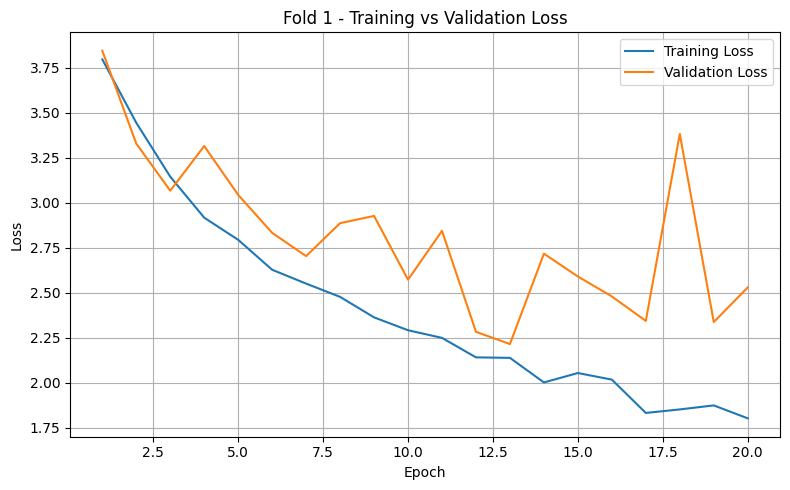

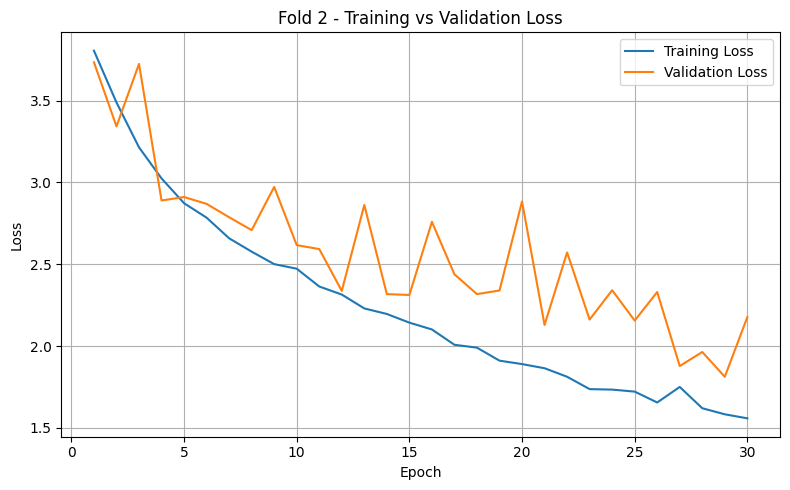

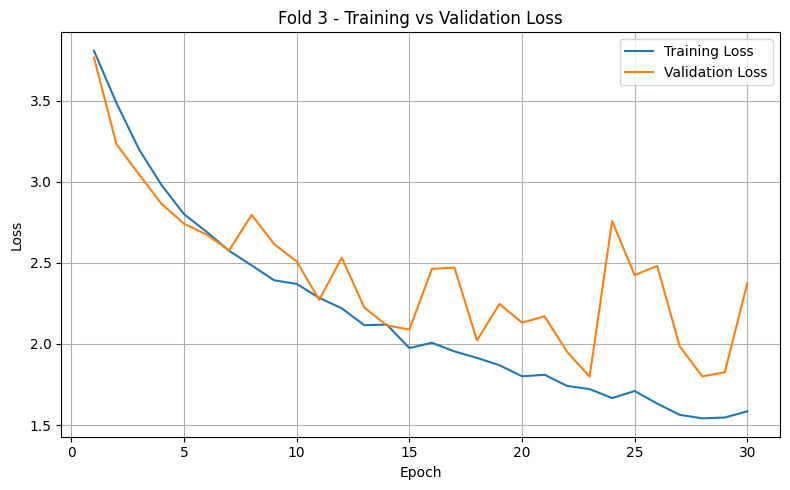

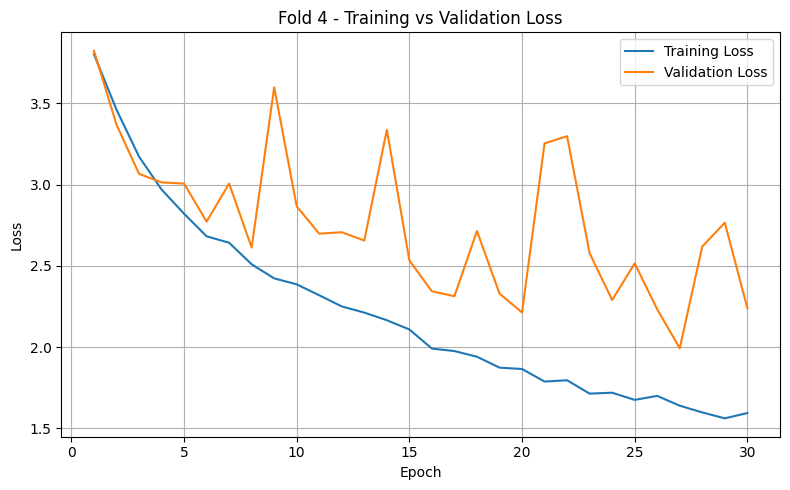

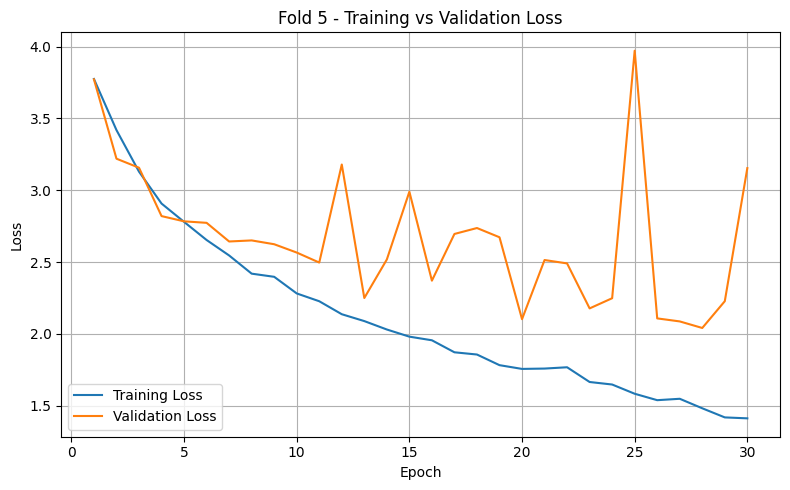

In [84]:
for fold_idx, history in enumerate(all_fold_histories, start=1):

    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        f"Fold {fold_idx} - Training vs Validation Loss"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

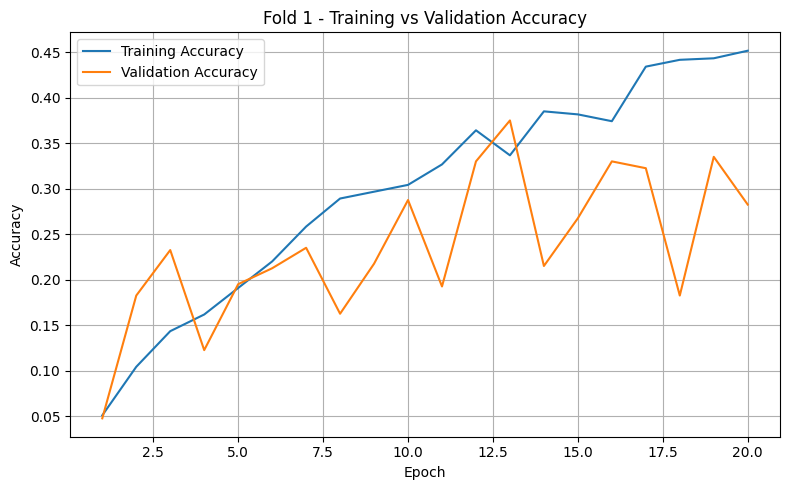

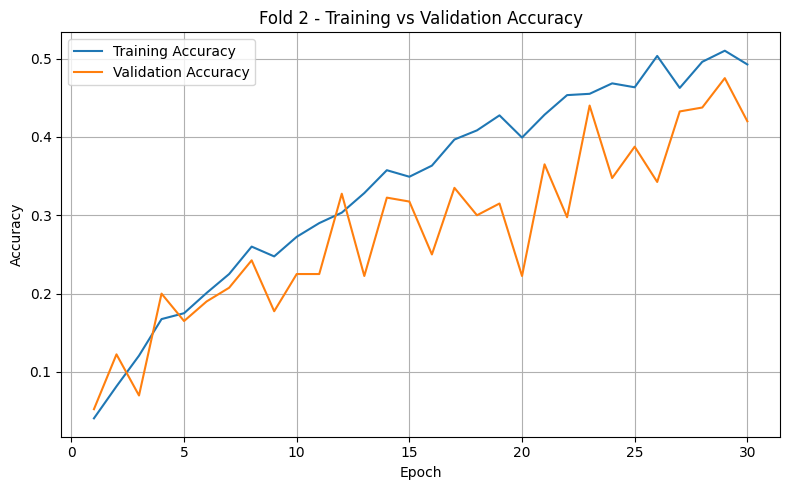

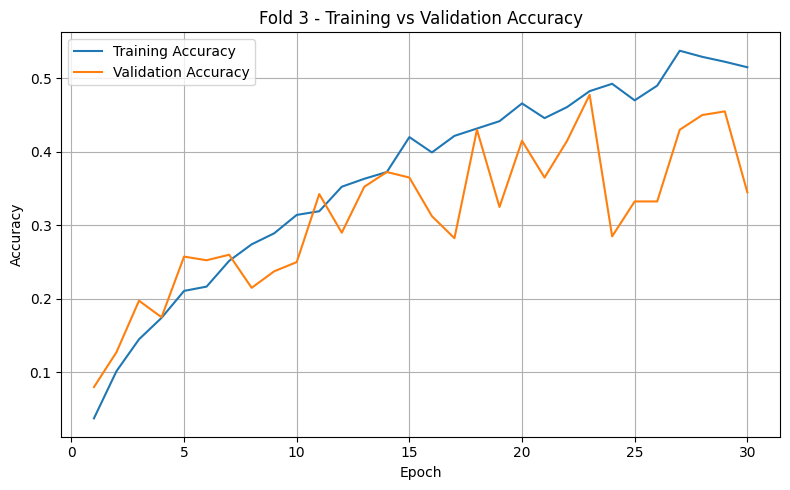

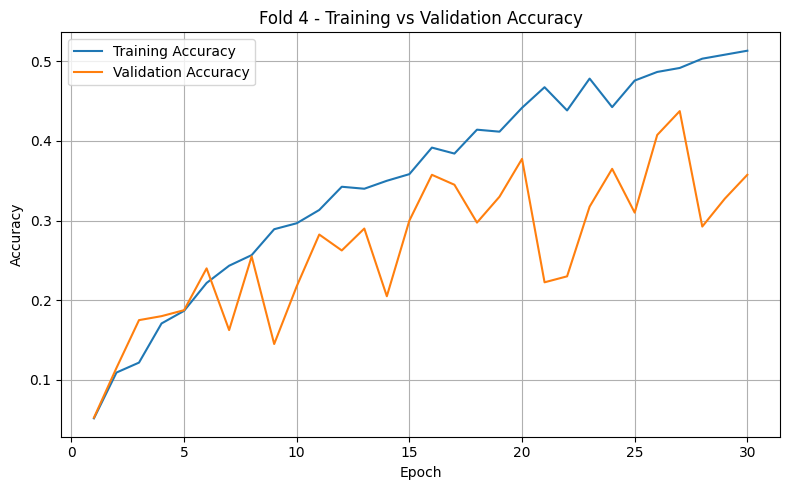

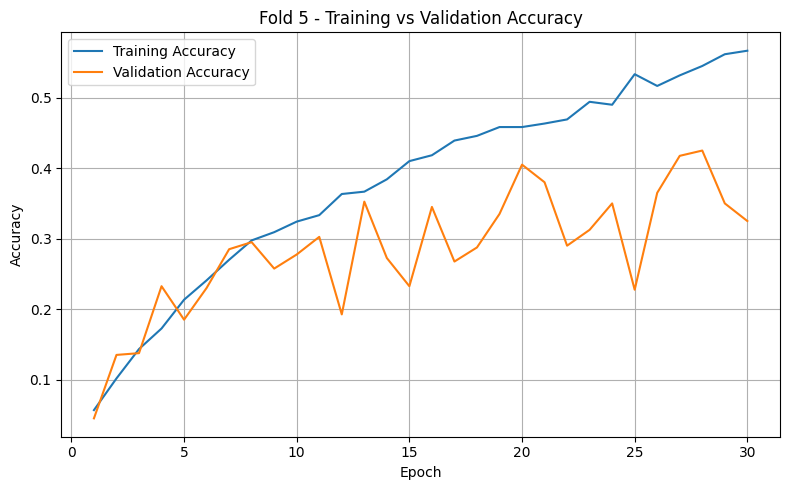

In [85]:
for fold_idx, history in enumerate(all_fold_histories, start=1):

    epochs = range(
        1,
        len(history["train_accuracy"]) + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(
        f"Fold {fold_idx} - Training vs Validation Accuracy"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

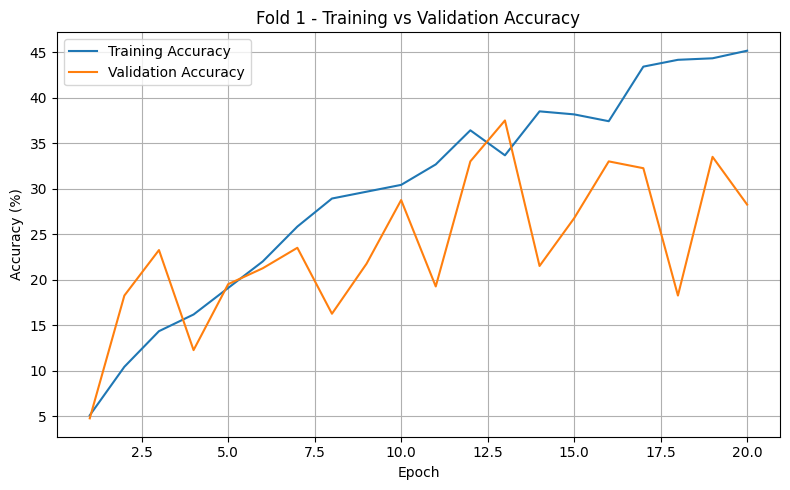

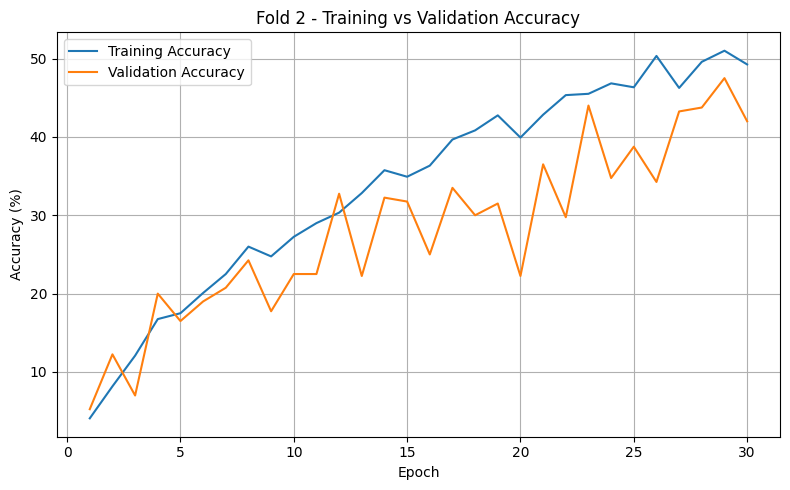

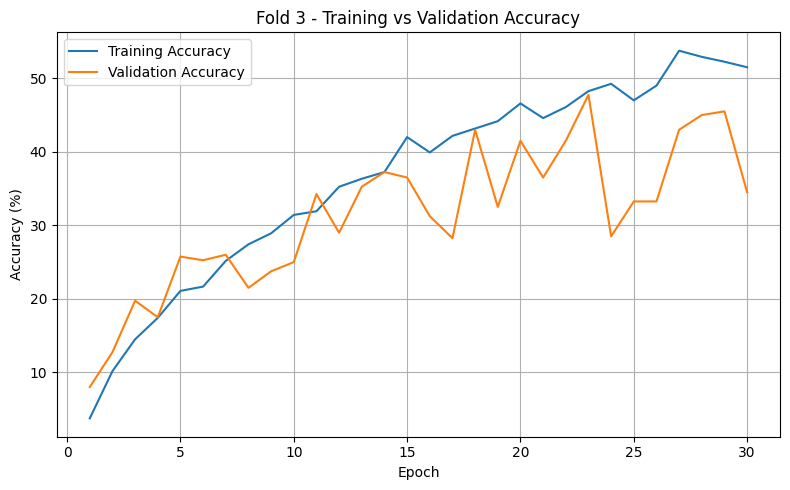

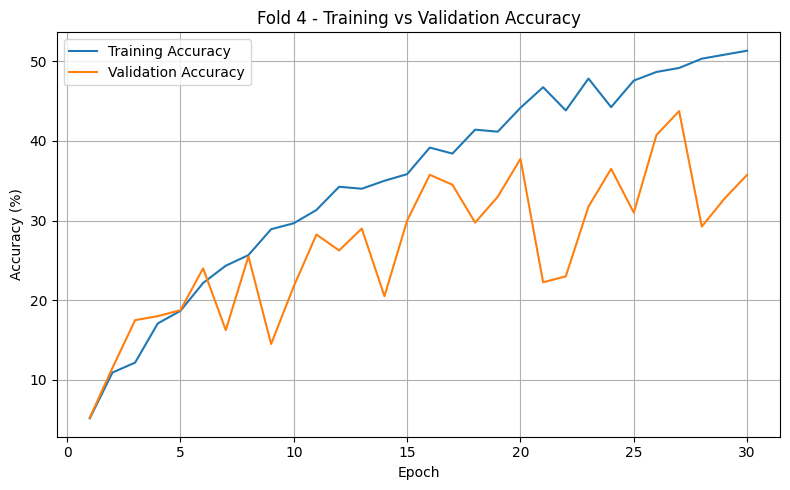

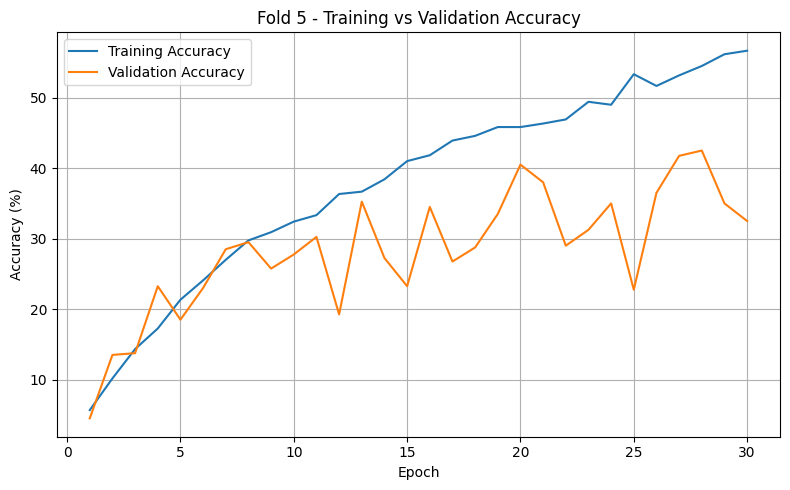

In [87]:
for fold_idx, history in enumerate(all_fold_histories, start=1):

    epochs = range(
        1,
        len(history["train_accuracy"]) + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        [x * 100 for x in history["train_accuracy"]],
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        [x * 100 for x in history["val_accuracy"]],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(
        f"Fold {fold_idx} - Training vs Validation Accuracy"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

In [88]:
print("=" * 70)
print("CROSS-VALIDATION TRAINING SUMMARY")
print("=" * 70)

for fold_idx, history in enumerate(
    all_fold_histories,
    start=1
):

    best_epoch = all_fold_best_epochs[fold_idx - 1]
    best_val_loss = all_fold_best_val_losses[fold_idx - 1]

    best_epoch_idx = best_epoch - 1

    best_val_accuracy = history[
        "val_accuracy"
    ][best_epoch_idx]

    train_accuracy_at_best = history[
        "train_accuracy"
    ][best_epoch_idx]

    print(
        f"Fold {fold_idx}: "
        f"Best Epoch = {best_epoch}, "
        f"Train Acc = {train_accuracy_at_best * 100:.2f}%, "
        f"Val Acc = {best_val_accuracy * 100:.2f}%, "
        f"Val Loss = {best_val_loss:.4f}"
    )

CROSS-VALIDATION TRAINING SUMMARY
Fold 1: Best Epoch = 13, Train Acc = 33.67%, Val Acc = 37.50%, Val Loss = 2.2147
Fold 2: Best Epoch = 29, Train Acc = 51.00%, Val Acc = 47.50%, Val Loss = 1.8123
Fold 3: Best Epoch = 23, Train Acc = 48.25%, Val Acc = 47.75%, Val Loss = 1.7988
Fold 4: Best Epoch = 27, Train Acc = 49.17%, Val Acc = 43.75%, Val Loss = 1.9934
Fold 5: Best Epoch = 28, Train Acc = 54.50%, Val Acc = 42.50%, Val Loss = 2.0407


In [89]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [100]:
def evaluate_model(
    model,
    dataloader,
    device
):
    """
    Evaluate a trained model on a test DataLoader.

    Returns:
        accuracy
        precision
        recall
        f1
        true_labels
        predicted_labels
        probabilities
    """

    model.eval()

    true_labels = []
    predicted_labels = []
    probabilities = []

    with torch.no_grad():

        for inputs, labels in dataloader:

            inputs = inputs.to(
                device,
                non_blocking=True
            )

            outputs = model(inputs)

            probs = torch.softmax(
                outputs,
                dim=1
            )

            predictions = torch.argmax(
                probs,
                dim=1
            )

            true_labels.extend(
                labels.numpy()
            )

            predicted_labels.extend(
                predictions.cpu().numpy()
            )

            probabilities.append(
                probs.cpu().numpy()
            )

    # --------------------------------------------------------
    # Convert stored predictions to NumPy arrays
    # --------------------------------------------------------

    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)
    probabilities = np.concatenate(
        probabilities,
        axis=0
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        true_labels,
        predicted_labels
    )

    precision = precision_score(
        true_labels,
        predicted_labels,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        true_labels,
        predicted_labels,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        true_labels,
        predicted_labels,
        average="macro",
        zero_division=0
    )

    return (
        accuracy,
        precision,
        recall,
        f1,
        true_labels,
        predicted_labels,
        probabilities
    )

In [101]:
fold_1_config = fold_configurations[0]

test_fold = fold_1_config["test_fold"]

_, _, test_df = create_fold_split(
    df,
    test_fold=test_fold,
    validation_fold=fold_1_config["validation_fold"]
)

test_dataset = ESC50Dataset(
    test_df,
    AUDIO_DIR,
    class_to_idx
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [102]:
(
    fold_1_accuracy,
    fold_1_precision,
    fold_1_recall,
    fold_1_f1,
    fold_1_true,
    fold_1_pred,
    fold_1_probs
) = evaluate_model(
    all_fold_models[0],
    test_loader,
    DEVICE
)

In [103]:
print("Fold 1 Test Results")
print("=" * 40)

print(
    f"Accuracy : {fold_1_accuracy * 100:.2f}%"
)

print(
    f"Precision: {fold_1_precision * 100:.2f}%"
)

print(
    f"Recall   : {fold_1_recall * 100:.2f}%"
)

print(
    f"F1 Score : {fold_1_f1 * 100:.2f}%"
)

Fold 1 Test Results
Accuracy : 37.75%
Precision: 38.44%
Recall   : 37.75%
F1 Score : 34.55%


In [104]:
print("Number of test samples:", len(fold_1_true))
print("Number of predictions:", len(fold_1_pred))

Number of test samples: 400
Number of predictions: 400


In [105]:
print("Probability shape:", fold_1_probs.shape)

Probability shape: (400, 50)


In [106]:
all_test_results = []

all_true_labels = []
all_predicted_labels = []
all_probabilities = []

In [107]:
for fold_idx, config in enumerate(
    fold_configurations
):

    fold_number = config["test_fold"]
    validation_fold = config["validation_fold"]

    print("=" * 70)
    print(
        f"EVALUATING FOLD {fold_number}"
    )
    print("=" * 70)

    # --------------------------------------------------------
    # Create test split
    # --------------------------------------------------------

    _, _, test_df = create_fold_split(
        df,
        test_fold=fold_number,
        validation_fold=validation_fold
    )

    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    test_dataset = ESC50Dataset(
        test_df,
        AUDIO_DIR,
        class_to_idx
    )

    # --------------------------------------------------------
    # DataLoader
    # --------------------------------------------------------

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # --------------------------------------------------------
    # Evaluate
    # --------------------------------------------------------

    (
        accuracy,
        precision,
        recall,
        f1,
        true_labels,
        predicted_labels,
        probabilities
    ) = evaluate_model(
        all_fold_models[fold_idx],
        test_loader,
        DEVICE
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    result = {
        "fold": fold_number,
        "test_accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    all_test_results.append(result)

    all_true_labels.append(
        true_labels
    )

    all_predicted_labels.append(
        predicted_labels
    )

    all_probabilities.append(
        probabilities
    )

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print(
        f"Test Accuracy: {accuracy * 100:.2f}%"
    )

    print(
        f"Precision:     {precision * 100:.2f}%"
    )

    print(
        f"Recall:        {recall * 100:.2f}%"
    )

    print(
        f"F1 Score:      {f1 * 100:.2f}%"
    )

    print()

EVALUATING FOLD 1
Test Accuracy: 37.75%
Precision:     38.44%
Recall:        37.75%
F1 Score:      34.55%

EVALUATING FOLD 2
Test Accuracy: 46.50%
Precision:     47.57%
Recall:        46.50%
F1 Score:      44.82%

EVALUATING FOLD 3
Test Accuracy: 43.25%
Precision:     44.82%
Recall:        43.25%
F1 Score:      40.63%

EVALUATING FOLD 4
Test Accuracy: 47.25%
Precision:     47.51%
Recall:        47.25%
F1 Score:      44.20%

EVALUATING FOLD 5
Test Accuracy: 44.00%
Precision:     42.43%
Recall:        44.00%
F1 Score:      40.32%



In [108]:
print("=" * 70)
print("5-FOLD TEST RESULTS")
print("=" * 70)

for result in all_test_results:

    print(
        f"Fold {result['fold']}: "
        f"Accuracy = {result['test_accuracy'] * 100:.2f}% | "
        f"Precision = {result['precision'] * 100:.2f}% | "
        f"Recall = {result['recall'] * 100:.2f}% | "
        f"F1 = {result['f1'] * 100:.2f}%"
    )

5-FOLD TEST RESULTS
Fold 1: Accuracy = 37.75% | Precision = 38.44% | Recall = 37.75% | F1 = 34.55%
Fold 2: Accuracy = 46.50% | Precision = 47.57% | Recall = 46.50% | F1 = 44.82%
Fold 3: Accuracy = 43.25% | Precision = 44.82% | Recall = 43.25% | F1 = 40.63%
Fold 4: Accuracy = 47.25% | Precision = 47.51% | Recall = 47.25% | F1 = 44.20%
Fold 5: Accuracy = 44.00% | Precision = 42.43% | Recall = 44.00% | F1 = 40.32%


In [109]:
for fold_idx in range(5):

    print(
        f"Fold {fold_idx + 1}: "
        f"{len(all_true_labels[fold_idx])} samples"
    )

Fold 1: 400 samples
Fold 2: 400 samples
Fold 3: 400 samples
Fold 4: 400 samples
Fold 5: 400 samples


In [110]:
import pandas as pd

In [111]:
results_df = pd.DataFrame(all_test_results)

results_df

,fold,test_accuracy,precision,recall,f1
0,1,0.3775,0.384444,0.3775,0.345529
1,2,0.4650,0.475654,0.4650,0.448213
2,3,0.4325,0.448183,0.4325,0.406279
3,4,0.4725,0.475083,0.4725,0.441969
4,5,0.4400,0.424256,0.4400,0.403224


In [112]:
results_percent_df = results_df.copy()

metric_columns = [
    "test_accuracy",
    "precision",
    "recall",
    "f1"
]

for column in metric_columns:
    results_percent_df[column] *= 100

results_percent_df

,fold,test_accuracy,precision,recall,f1
0,1,37.75,38.444392,37.75,34.552932
1,2,46.50,47.565351,46.50,44.821305
2,3,43.25,44.818251,43.25,40.627922
3,4,47.25,47.508309,47.25,44.196892
4,5,44.00,42.425632,44.00,40.322411


In [113]:
mean_metrics = results_df[metric_columns].mean()
std_metrics = results_df[metric_columns].std()

print("=" * 60)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)

for metric in metric_columns:

    print(
        f"{metric}: "
        f"{mean_metrics[metric] * 100:.2f}% "
        f"± "
        f"{std_metrics[metric] * 100:.2f}%"
    )

5-FOLD CROSS-VALIDATION RESULTS
test_accuracy: 43.75% ± 3.75%
precision: 44.15% ± 3.84%
recall: 43.75% ± 3.75%
f1: 40.90% ± 4.09%


In [114]:
summary_df = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Mean (%)": [
        mean_metrics["test_accuracy"] * 100,
        mean_metrics["precision"] * 100,
        mean_metrics["recall"] * 100,
        mean_metrics["f1"] * 100
    ],
    "Std. Dev. (%)": [
        std_metrics["test_accuracy"] * 100,
        std_metrics["precision"] * 100,
        std_metrics["recall"] * 100,
        std_metrics["f1"] * 100
    ]
})

summary_df["Mean (%)"] = summary_df["Mean (%)"].round(2)
summary_df["Std. Dev. (%)"] = summary_df["Std. Dev. (%)"].round(2)

summary_df

,Metric,Mean (%),Std. Dev. (%)
0,Test Accuracy,43.75,3.75
1,Precision,44.15,3.84
2,Recall,43.75,3.75
3,F1 Score,40.90,4.09


In [115]:
fold_results_display = results_percent_df.copy()

fold_results_display = fold_results_display.rename(
    columns={
        "fold": "Fold",
        "test_accuracy": "Test Accuracy (%)",
        "precision": "Precision (%)",
        "recall": "Recall (%)",
        "f1": "F1 Score (%)"
    }
)

for column in [
    "Test Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1 Score (%)"
]:
    fold_results_display[column] = (
        fold_results_display[column]
        .round(2)
    )

fold_results_display

,Fold,Test Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,1,37.75,38.44,37.75,34.55
1,2,46.50,47.57,46.50,44.82
2,3,43.25,44.82,43.25,40.63
3,4,47.25,47.51,47.25,44.20
4,5,44.00,42.43,44.00,40.32


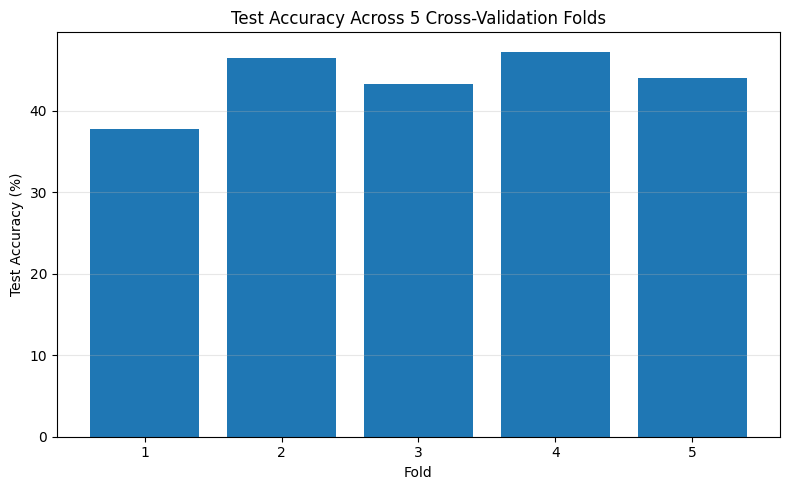

In [116]:
plt.figure(figsize=(8, 5))

plt.bar(
    fold_results_display["Fold"],
    fold_results_display["Test Accuracy (%)"]
)

plt.xlabel("Fold")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Across 5 Cross-Validation Folds")

plt.xticks(
    range(1, 6)
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

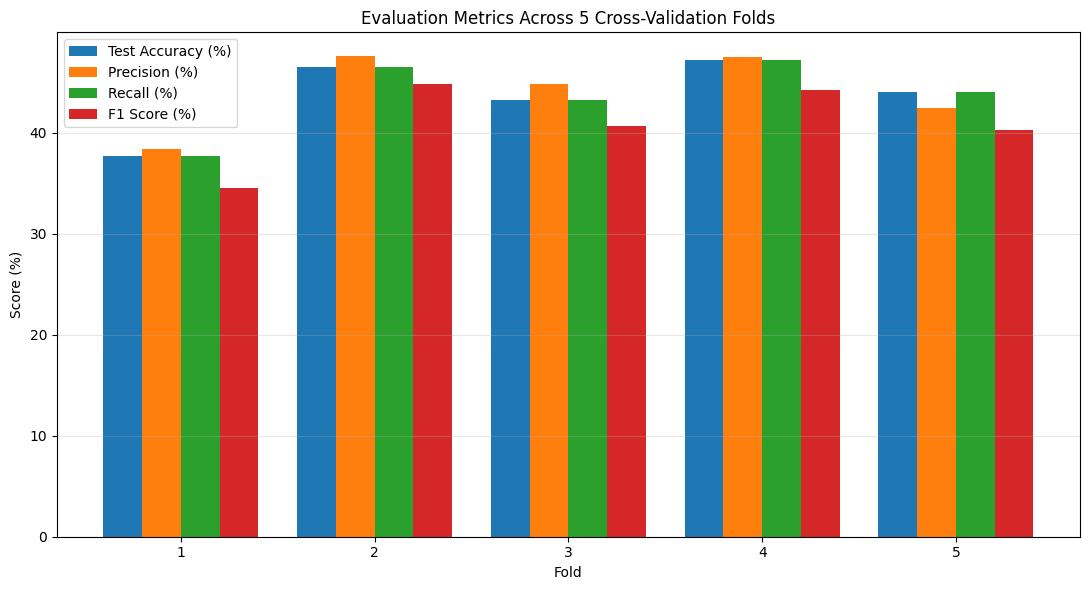

In [117]:
metrics_to_plot = [
    "Test Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1 Score (%)"
]

x = np.arange(len(fold_results_display["Fold"]))

width = 0.2

plt.figure(figsize=(11, 6))

for i, metric in enumerate(metrics_to_plot):

    plt.bar(
        x + (i - 1.5) * width,
        fold_results_display[metric],
        width,
        label=metric
    )

plt.xlabel("Fold")
plt.ylabel("Score (%)")
plt.title(
    "Evaluation Metrics Across 5 Cross-Validation Folds"
)

plt.xticks(
    x,
    fold_results_display["Fold"]
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [118]:
best_fold = results_df.loc[
    results_df["test_accuracy"].idxmax()
]

worst_fold = results_df.loc[
    results_df["test_accuracy"].idxmin()
]

print(
    f"Best fold: Fold {int(best_fold['fold'])}"
)

print(
    f"Best test accuracy: "
    f"{best_fold['test_accuracy'] * 100:.2f}%"
)

print()

print(
    f"Worst fold: Fold {int(worst_fold['fold'])}"
)

print(
    f"Worst test accuracy: "
    f"{worst_fold['test_accuracy'] * 100:.2f}%"
)

Best fold: Fold 4
Best test accuracy: 47.25%

Worst fold: Fold 1
Worst test accuracy: 37.75%


In [119]:
all_true_combined = np.concatenate(
    all_true_labels,
    axis=0
)

all_pred_combined = np.concatenate(
    all_predicted_labels,
    axis=0
)

print(
    "Total true labels:",
    len(all_true_combined)
)

print(
    "Total predictions:",
    len(all_pred_combined)
)

Total true labels: 2000
Total predictions: 2000


In [120]:
from sklearn.metrics import confusion_matrix

In [121]:
cm = confusion_matrix(
    all_true_combined,
    all_pred_combined,
    labels=range(len(class_names))
)

print("Confusion matrix shape:", cm.shape)

Confusion matrix shape: (50, 50)


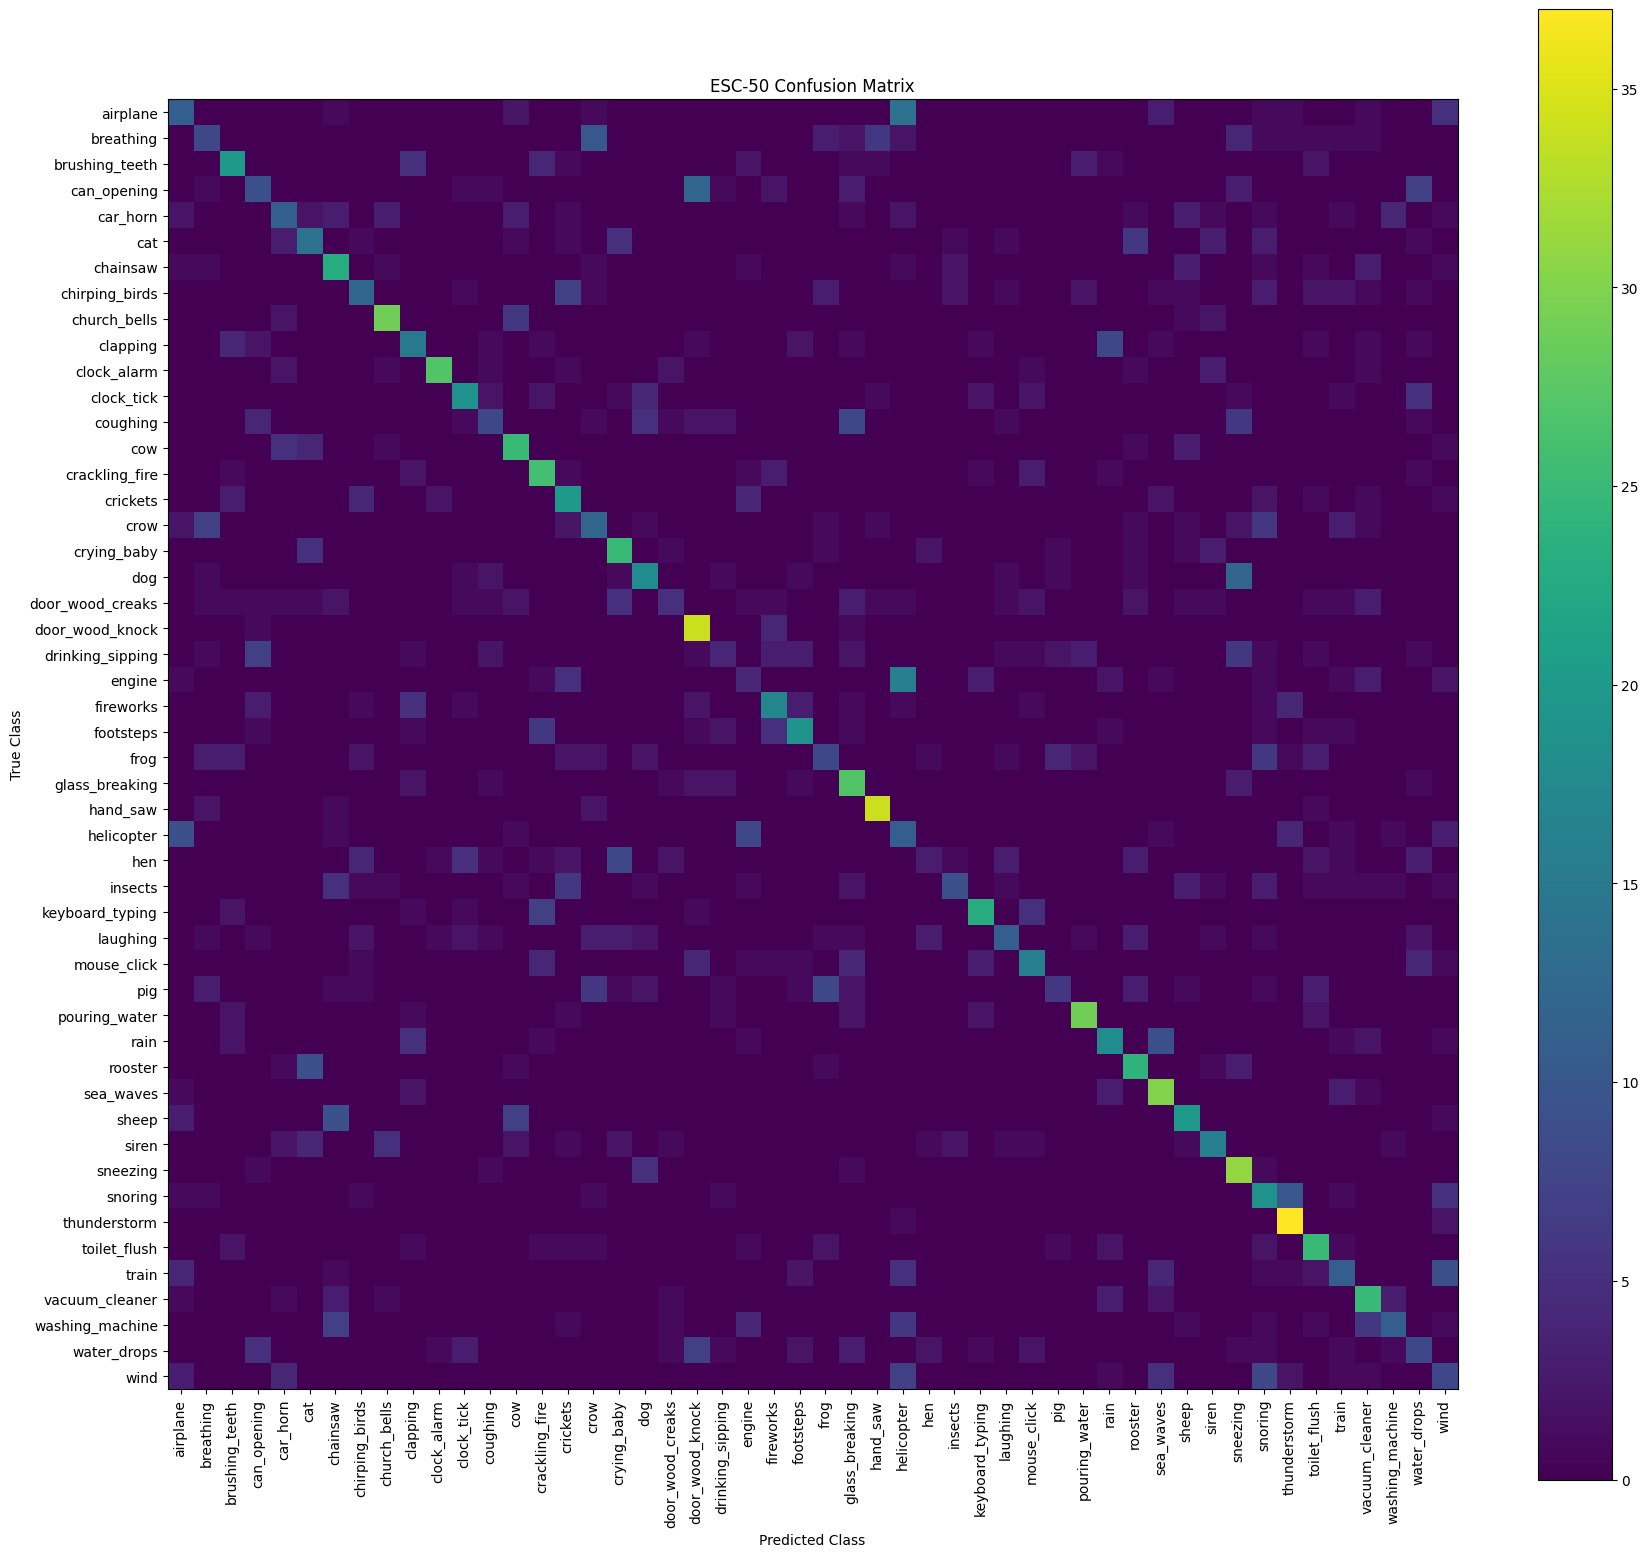

In [122]:
plt.figure(figsize=(18, 16))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "ESC-50 Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()

plt.show()

In [123]:
cm_normalized = (
    cm.astype("float")
    / cm.sum(axis=1, keepdims=True)
)

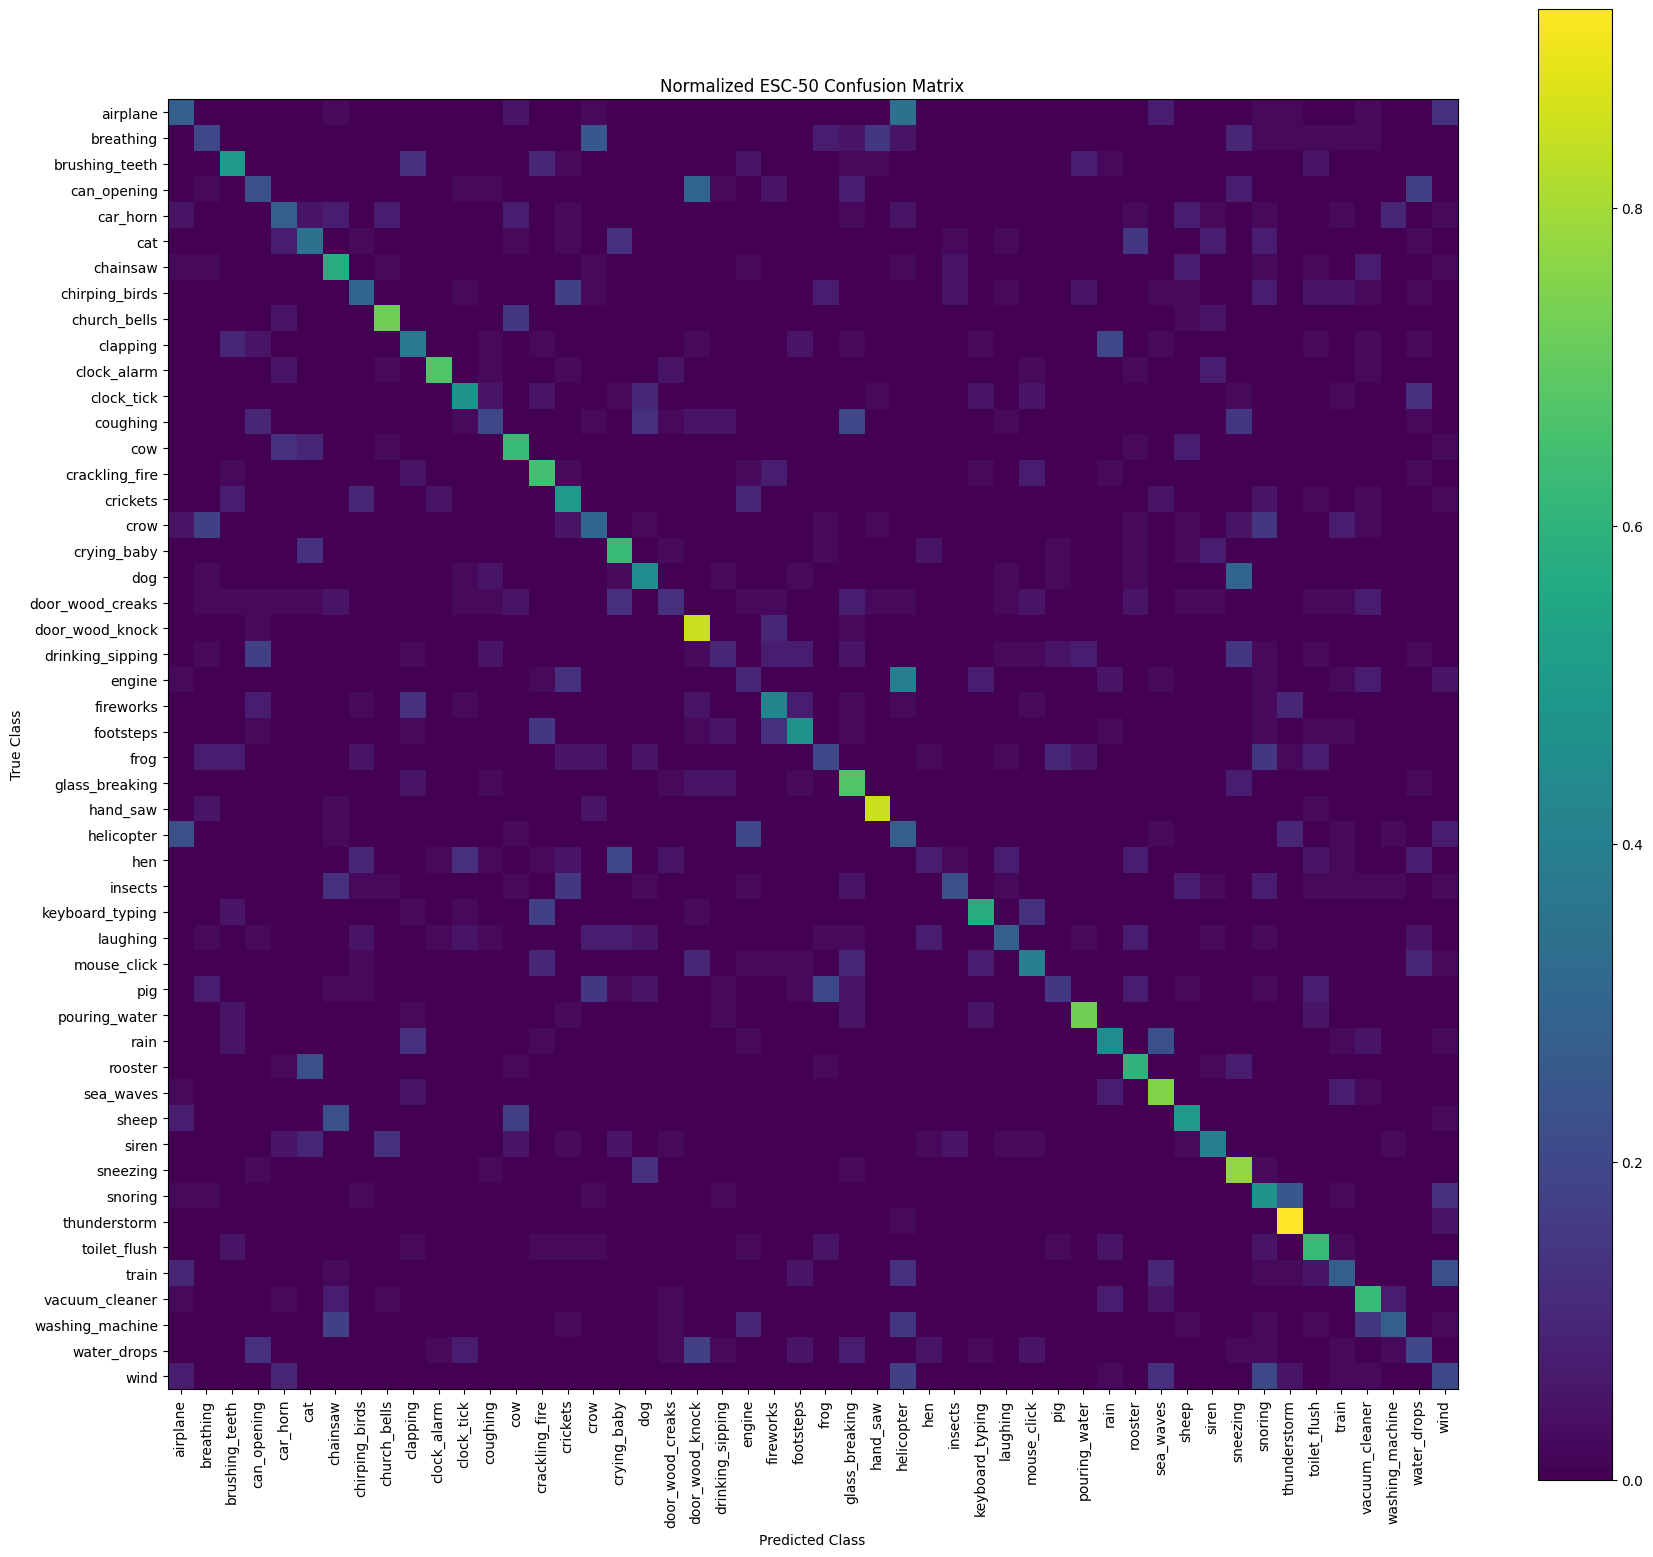

In [124]:
plt.figure(figsize=(18, 16))

plt.imshow(
    cm_normalized,
    interpolation="nearest"
)

plt.title(
    "Normalized ESC-50 Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()

plt.show()

In [125]:
per_class_accuracy = (
    np.diag(cm)
    / cm.sum(axis=1)
)

In [126]:
per_class_df = pd.DataFrame({
    "Class": class_names,
    "Accuracy": per_class_accuracy
})

per_class_df["Accuracy (%)"] = (
    per_class_df["Accuracy"] * 100
)

per_class_df = per_class_df.drop(
    columns=["Accuracy"]
)

per_class_df = per_class_df.sort_values(
    "Accuracy (%)",
    ascending=False
)

per_class_df

,Class,Accuracy (%)
43,thunderstorm,92.5
20,door_wood_knock,85.0
27,hand_saw,85.0
41,sneezing,77.5
38,sea_waves,75.0
35,pouring_water,72.5
8,church_bells,72.5
26,glass_breaking,67.5
10,clock_alarm,67.5
14,crackling_fire,65.0


In [127]:
print("Top 10 best-classified categories:")

per_class_df.head(10)

Top 10 best-classified categories:


,Class,Accuracy (%)
43,thunderstorm,92.5
20,door_wood_knock,85.0
27,hand_saw,85.0
41,sneezing,77.5
38,sea_waves,75.0
35,pouring_water,72.5
8,church_bells,72.5
26,glass_breaking,67.5
10,clock_alarm,67.5
14,crackling_fire,65.0


In [128]:
print("Top 10 most difficult categories:")

per_class_df.tail(10).sort_values(
    "Accuracy (%)"
)

Top 10 most difficult categories:


,Class,Accuracy (%)
29,hen,7.5
21,drinking_sipping,10.0
22,engine,10.0
19,door_wood_creaks,12.5
34,pig,15.0
25,frog,20.0
48,water_drops,20.0
12,coughing,20.0
49,wind,20.0
1,breathing,20.0


In [129]:
confusion_pairs = []

for true_idx in range(len(class_names)):

    for pred_idx in range(len(class_names)):

        if true_idx == pred_idx:
            continue

        count = cm[
            true_idx,
            pred_idx
        ]

        if count > 0:

            confusion_pairs.append({
                "True Class": class_names[true_idx],
                "Predicted Class": class_names[pred_idx],
                "Count": count
            })

In [130]:
confusion_pairs_df = pd.DataFrame(
    confusion_pairs
)

confusion_pairs_df = confusion_pairs_df.sort_values(
    "Count",
    ascending=False
)

In [131]:
confusion_pairs_df.head(15)

,True Class,Predicted Class,Count
236,engine,helicopter,16
3,airplane,helicopter,14
190,dog,sneezing,12
32,can_opening,door_wood_knock,12
9,breathing,crow,10
431,snoring,thunderstorm,10
455,train,wind,9
405,sheep,chainsaw,9
394,rooster,cat,9
389,rain,sea_waves,9


In [132]:
final_dataset = ESC50Dataset(
    dataframe=df,
    audio_dir=AUDIO_DIR,
    class_to_idx=class_to_idx
)

final_loader = DataLoader(
    final_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Final dataset size:", len(final_dataset))
print("Final batches:", len(final_loader))

Final dataset size: 2000
Final batches: 63


In [135]:
final_model = ESC50CNN(
    num_classes=len(class_names),
    dropout=DROPOUT
).to(DEVICE)

In [136]:
print(final_model)

ESC50CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    

In [137]:
final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=0.001
)

In [138]:
final_criterion = nn.CrossEntropyLoss()

In [139]:
final_history = {
    "train_loss": [],
    "train_accuracy": []
}

In [140]:
NUM_EPOCHS = 30

In [145]:
# ============================================================
# FINAL MODEL TRAINING
# ============================================================

final_model.train()

for epoch in range(NUM_EPOCHS):

    running_loss = 0.0
    correct = 0
    total = 0

    epoch_start = time.time()

    for inputs, labels in final_loader:

        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        final_optimizer.zero_grad()

        outputs = final_model(inputs)

        loss = final_criterion(outputs, labels)

        loss.backward()

        final_optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    final_history["train_loss"].append(epoch_loss)
    final_history["train_accuracy"].append(epoch_accuracy)

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Train Acc: {epoch_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

Epoch 01/30 | Train Loss: 3.7228 | Train Acc: 0.0520 | Time: 47.6s
Epoch 02/30 | Train Loss: 3.2705 | Train Acc: 0.1180 | Time: 46.6s
Epoch 03/30 | Train Loss: 2.9565 | Train Acc: 0.1610 | Time: 43.5s
Epoch 04/30 | Train Loss: 2.7489 | Train Acc: 0.2025 | Time: 47.7s
Epoch 05/30 | Train Loss: 2.6233 | Train Acc: 0.2345 | Time: 44.1s
Epoch 06/30 | Train Loss: 2.4653 | Train Acc: 0.2780 | Time: 48.2s
Epoch 07/30 | Train Loss: 2.3509 | Train Acc: 0.3100 | Time: 45.0s
Epoch 08/30 | Train Loss: 2.2521 | Train Acc: 0.3310 | Time: 44.6s
Epoch 09/30 | Train Loss: 2.1615 | Train Acc: 0.3480 | Time: 45.7s
Epoch 10/30 | Train Loss: 2.0748 | Train Acc: 0.3775 | Time: 44.7s
Epoch 11/30 | Train Loss: 2.0204 | Train Acc: 0.3880 | Time: 45.8s
Epoch 12/30 | Train Loss: 1.9544 | Train Acc: 0.4150 | Time: 46.8s
Epoch 13/30 | Train Loss: 1.8320 | Train Acc: 0.4580 | Time: 45.3s
Epoch 14/30 | Train Loss: 1.8036 | Train Acc: 0.4605 | Time: 44.5s
Epoch 15/30 | Train Loss: 1.7479 | Train Acc: 0.4460 | Time: 4

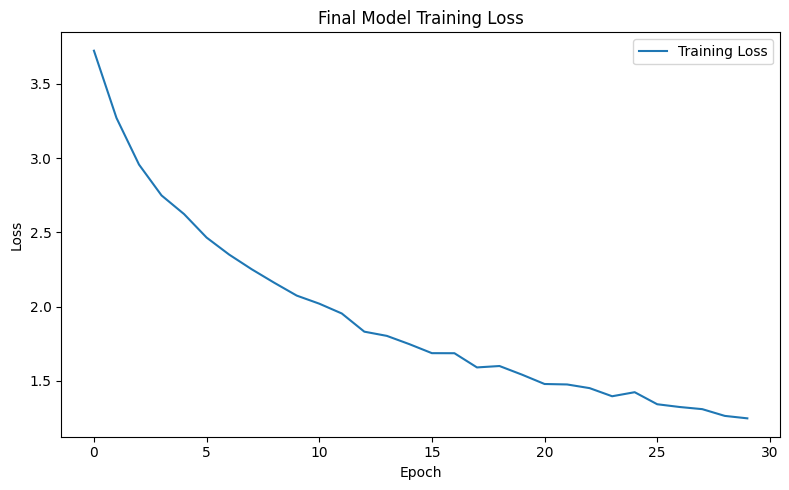

In [146]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history["train_loss"],
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model Training Loss")

plt.legend()
plt.tight_layout()
plt.show()

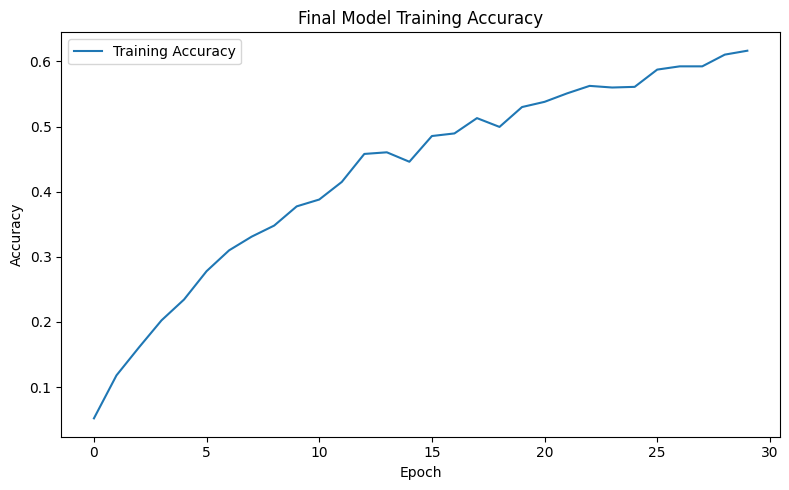

In [147]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history["train_accuracy"],
    label="Training Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Model Training Accuracy")

plt.legend()
plt.tight_layout()
plt.show()

In [148]:
FINAL_MODEL_PATH = "final_environmental_sound_cnn.pth"

torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "class_names": class_names,
        "class_to_idx": class_to_idx,
        "num_classes": len(class_names)
    },
    FINAL_MODEL_PATH
)

print("Final model saved to:", FINAL_MODEL_PATH)

Final model saved to: final_environmental_sound_cnn.pth


In [149]:
verification_model = ESC50CNN(
    num_classes=len(class_names),
    dropout=DROPOUT
).to(DEVICE)

checkpoint = torch.load(
    FINAL_MODEL_PATH,
    map_location=DEVICE
)

verification_model.load_state_dict(
    checkpoint["model_state_dict"]
)

verification_model.eval()

print("Final model checkpoint loaded successfully.")

Final model checkpoint loaded successfully.


In [150]:
final_model.eval()

print("Final model is ready for evaluation.")

Final model is ready for evaluation.


In [151]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

final_model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)

        outputs = final_model(inputs)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

print("Test samples:", len(all_targets))
print("Predictions:", len(all_predictions))

Test samples: 400
Predictions: 400


In [152]:
final_accuracy = accuracy_score(
    all_targets,
    all_predictions
)

final_precision = precision_score(
    all_targets,
    all_predictions,
    average="macro",
    zero_division=0
)

final_recall = recall_score(
    all_targets,
    all_predictions,
    average="macro",
    zero_division=0
)

final_f1 = f1_score(
    all_targets,
    all_predictions,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("FINAL MODEL TEST RESULTS")
print("=" * 60)

print(f"Accuracy : {final_accuracy * 100:.2f}%")
print(f"Precision: {final_precision * 100:.2f}%")
print(f"Recall   : {final_recall * 100:.2f}%")
print(f"F1 Score : {final_f1 * 100:.2f}%")

FINAL MODEL TEST RESULTS
Accuracy : 59.50%
Precision: 67.42%
Recall   : 59.50%
F1 Score : 57.24%


In [153]:
print("\nClassification Report:\n")

print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


Classification Report:

                  precision    recall  f1-score   support

        airplane     0.4286    0.7500    0.5455         8
       breathing     0.2778    0.6250    0.3846         8
  brushing_teeth     0.5556    0.6250    0.5882         8
     can_opening     1.0000    0.1250    0.2222         8
        car_horn     0.8333    0.6250    0.7143         8
             cat     1.0000    0.6250    0.7692         8
        chainsaw     0.3077    1.0000    0.4706         8
  chirping_birds     1.0000    0.5000    0.6667         8
    church_bells     0.8000    1.0000    0.8889         8
        clapping     0.3333    0.3750    0.3529         8
     clock_alarm     0.8889    1.0000    0.9412         8
      clock_tick     0.7143    0.6250    0.6667         8
        coughing     0.5000    0.2500    0.3333         8
             cow     0.8750    0.8750    0.8750         8
  crackling_fire     0.4615    0.7500    0.5714         8
        crickets     0.7778    0.8750    0.823

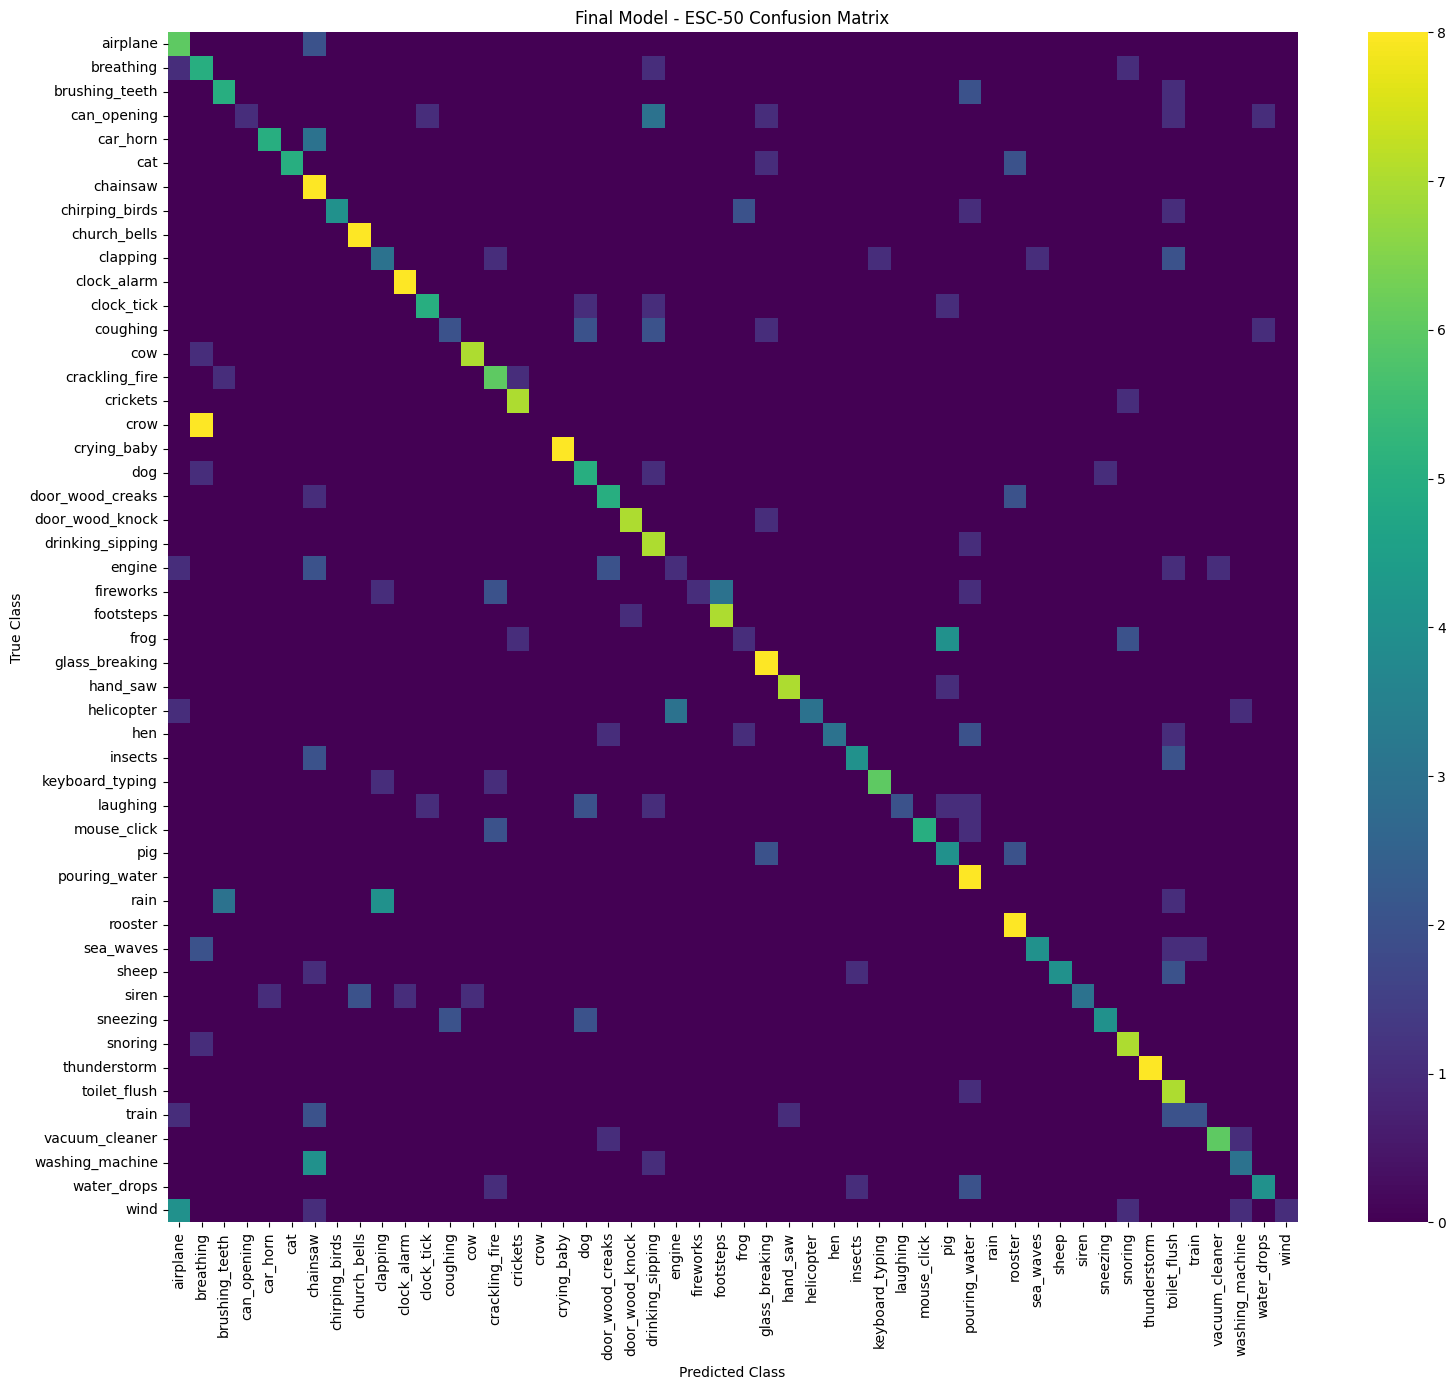

In [154]:
final_cm = confusion_matrix(
    all_targets,
    all_predictions
)

plt.figure(figsize=(16, 14))

sns.heatmap(
    final_cm,
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Final Model - ESC-50 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

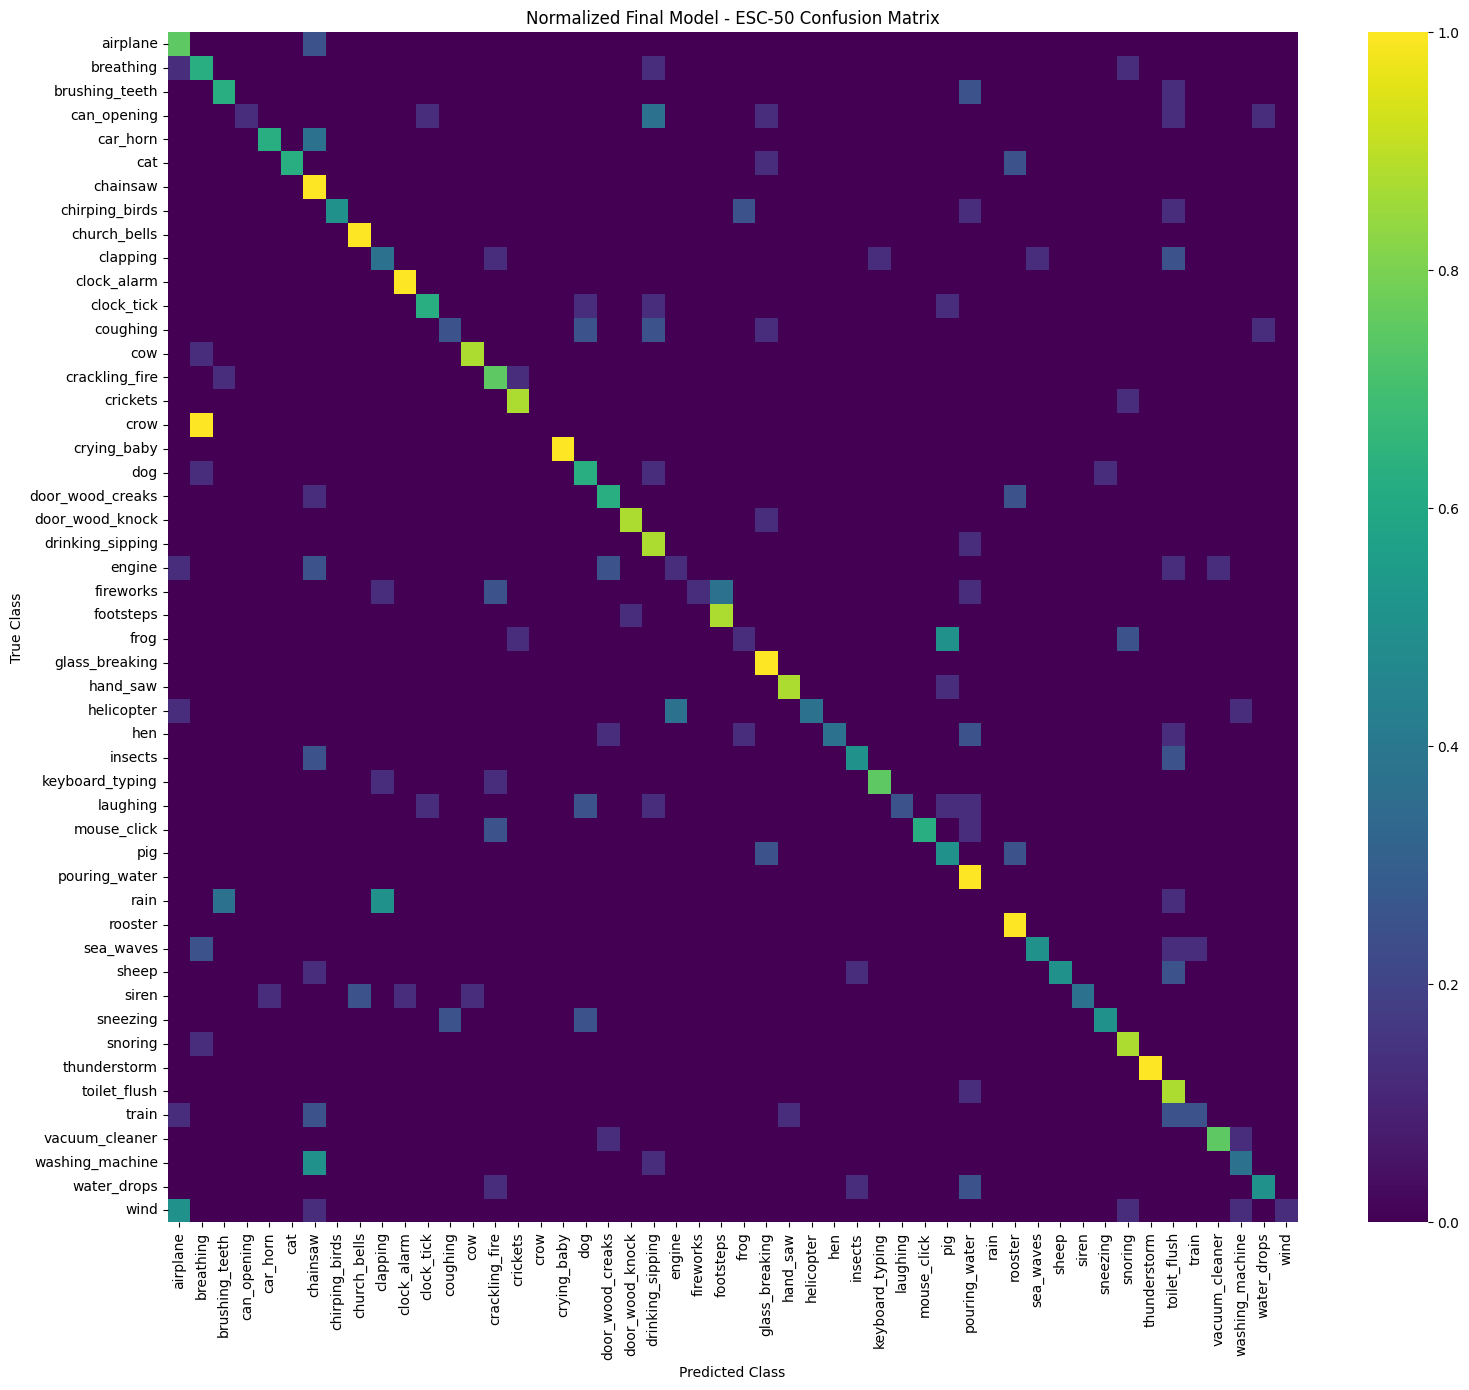

In [155]:
final_cm_normalized = (
    final_cm.astype("float")
    / final_cm.sum(axis=1, keepdims=True)
)

plt.figure(figsize=(16, 14))

sns.heatmap(
    final_cm_normalized,
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1
)

plt.title("Normalized Final Model - ESC-50 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [156]:
final_metrics = {
    "accuracy": final_accuracy,
    "precision_macro": final_precision,
    "recall_macro": final_recall,
    "f1_macro": final_f1
}

print("\nFinal metrics dictionary:")
print(final_metrics)


Final metrics dictionary:
{'accuracy': 0.595, 'precision_macro': 0.6742007175830704, 'recall_macro': 0.595, 'f1_macro': 0.5723968552603228}


In [158]:
# ============================================================
# PHASE 15.1 — FINAL OVERALL METRICS
# ============================================================

print("=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy       : {final_accuracy * 100:.2f}%")
print(f"Macro Precision: {final_precision * 100:.2f}%")
print(f"Macro Recall   : {final_recall * 100:.2f}%")
print(f"Macro F1 Score : {final_f1 * 100:.2f}%")

FINAL MODEL PERFORMANCE
Accuracy       : 59.50%
Macro Precision: 67.42%
Macro Recall   : 59.50%
Macro F1 Score : 57.24%


In [159]:
# ============================================================
# PHASE 15.2 — FINAL MODEL PER-CLASS PERFORMANCE
# ============================================================

final_cm = confusion_matrix(
    all_targets,
    all_predictions,
    labels=range(len(class_names))
)

final_per_class_accuracy = (
    np.diag(final_cm)
    / final_cm.sum(axis=1)
)

final_per_class_df = pd.DataFrame({
    "Class": class_names,
    "Accuracy": final_per_class_accuracy
})

final_per_class_df["Accuracy (%)"] = (
    final_per_class_df["Accuracy"] * 100
)

final_per_class_df = final_per_class_df.drop(
    columns=["Accuracy"]
)

final_per_class_df = final_per_class_df.sort_values(
    "Accuracy (%)",
    ascending=False
)

final_per_class_df

,Class,Accuracy (%)
6,chainsaw,100.0
8,church_bells,100.0
17,crying_baby,100.0
10,clock_alarm,100.0
43,thunderstorm,100.0
26,glass_breaking,100.0
35,pouring_water,100.0
37,rooster,100.0
13,cow,87.5
15,crickets,87.5


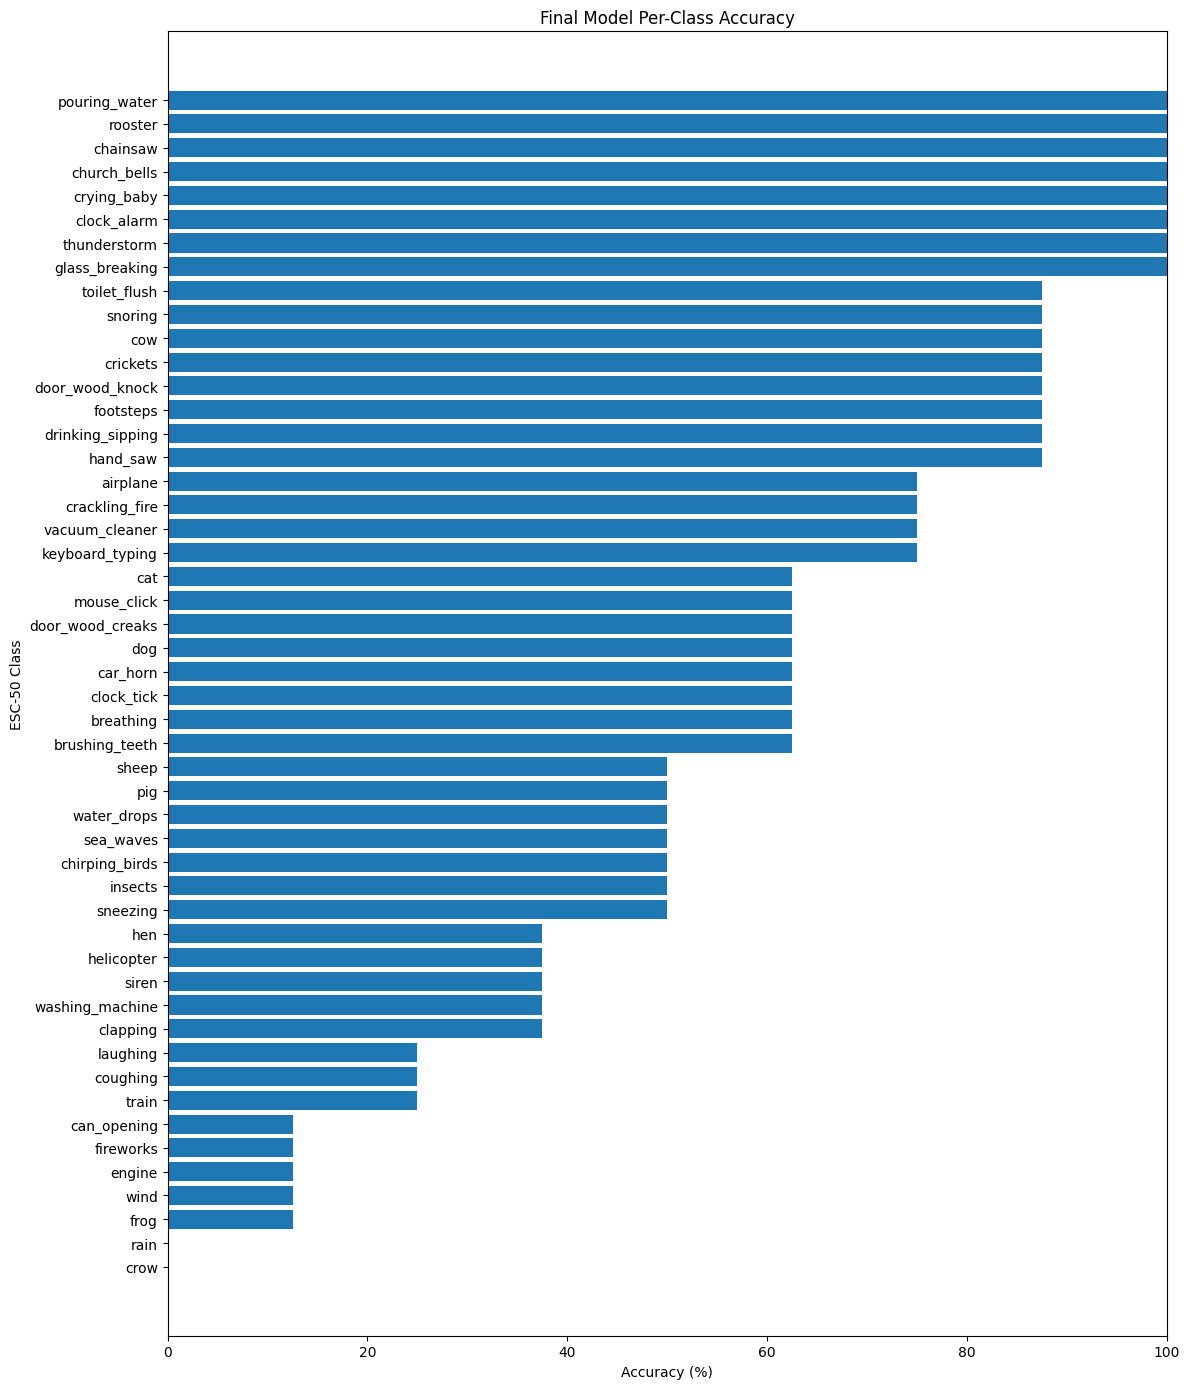

In [160]:
# ============================================================
# PHASE 15.3 — FINAL MODEL PER-CLASS ACCURACY
# ============================================================

plt.figure(figsize=(12, 14))

sorted_final_classes = final_per_class_df.sort_values(
    "Accuracy (%)",
    ascending=True
)

plt.barh(
    sorted_final_classes["Class"],
    sorted_final_classes["Accuracy (%)"]
)

plt.xlabel("Accuracy (%)")
plt.ylabel("ESC-50 Class")
plt.title("Final Model Per-Class Accuracy")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

In [161]:
# ============================================================
# PHASE 15.4 — BEST AND WORST CLASSES
# ============================================================

print("TOP 10 BEST-CLASSIFIED CATEGORIES")
print("=" * 50)

display(
    final_per_class_df.head(10)
)

print()
print("TOP 10 MOST DIFFICULT CATEGORIES")
print("=" * 50)

display(
    final_per_class_df
    .sort_values("Accuracy (%)", ascending=True)
    .head(10)
)

TOP 10 BEST-CLASSIFIED CATEGORIES


,Class,Accuracy (%)
6,chainsaw,100.0
8,church_bells,100.0
17,crying_baby,100.0
10,clock_alarm,100.0
43,thunderstorm,100.0
26,glass_breaking,100.0
35,pouring_water,100.0
37,rooster,100.0
13,cow,87.5
15,crickets,87.5



TOP 10 MOST DIFFICULT CATEGORIES


,Class,Accuracy (%)
16,crow,0.0
36,rain,0.0
25,frog,12.5
49,wind,12.5
22,engine,12.5
23,fireworks,12.5
3,can_opening,12.5
45,train,25.0
12,coughing,25.0
32,laughing,25.0


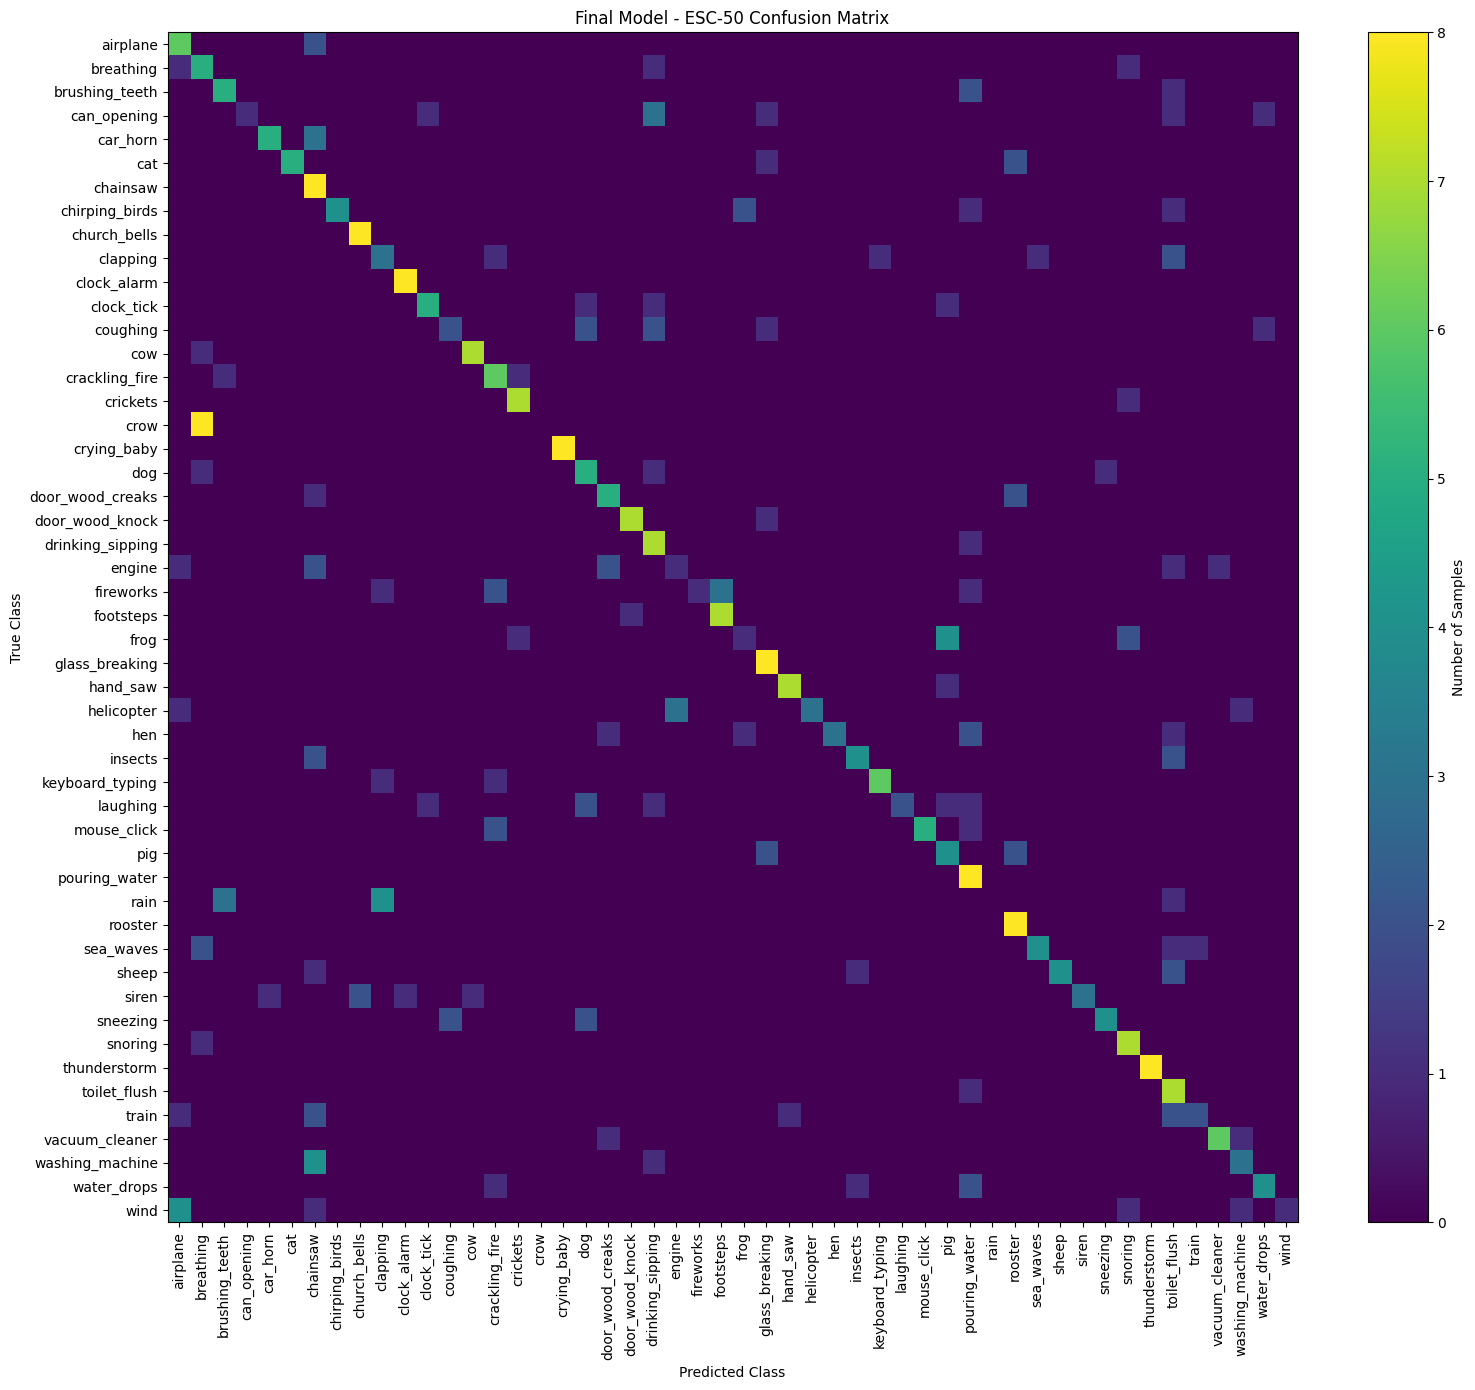

In [162]:
# ============================================================
# PHASE 15.5 — FINAL MODEL CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(16, 14))

plt.imshow(
    final_cm,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar(label="Number of Samples")

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Final Model - ESC-50 Confusion Matrix")

plt.tight_layout()
plt.show()

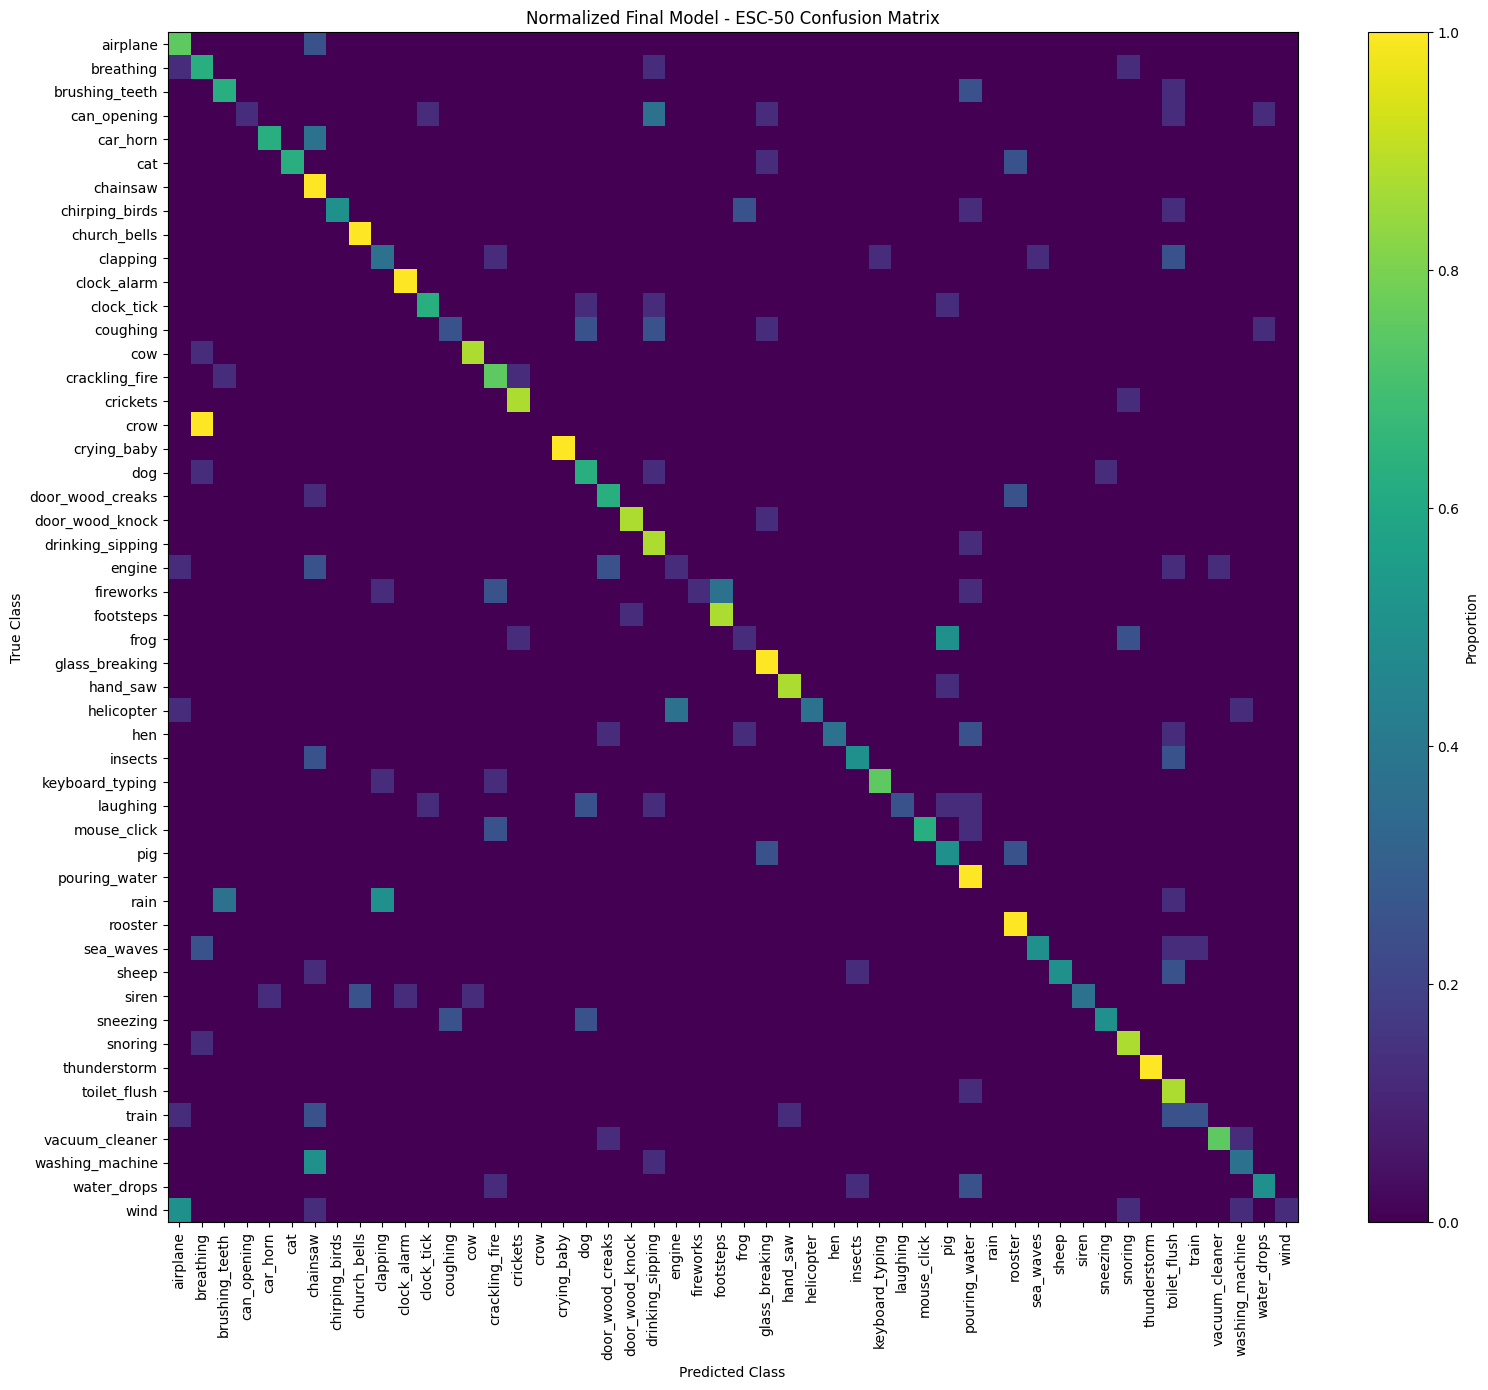

In [163]:
# ============================================================
# PHASE 15.6 — NORMALIZED CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(16, 14))

plt.imshow(
    final_cm_normalized,
    interpolation="nearest",
    aspect="auto",
    vmin=0,
    vmax=1
)

plt.colorbar(label="Proportion")

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Normalized Final Model - ESC-50 Confusion Matrix")

plt.tight_layout()
plt.show()

In [164]:
# ============================================================
# PHASE 15.7 — MOST CONFUSED CLASS PAIRS
# ============================================================

final_confusion_pairs = []

for true_idx in range(len(class_names)):

    for pred_idx in range(len(class_names)):

        if true_idx == pred_idx:
            continue

        count = final_cm[
            true_idx,
            pred_idx
        ]

        if count > 0:

            final_confusion_pairs.append({
                "True Class": class_names[true_idx],
                "Predicted Class": class_names[pred_idx],
                "Count": int(count)
            })

final_confusion_pairs_df = pd.DataFrame(
    final_confusion_pairs
)

final_confusion_pairs_df = (
    final_confusion_pairs_df
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

final_confusion_pairs_df.head(15)

,True Class,Predicted Class,Count
0,crow,breathing,8
1,frog,pig,4
2,rain,clapping,4
3,washing_machine,chainsaw,4
4,wind,airplane,4
5,rain,brushing_teeth,3
6,car_horn,chainsaw,3
7,helicopter,engine,3
8,fireworks,footsteps,3
9,can_opening,drinking_sipping,3


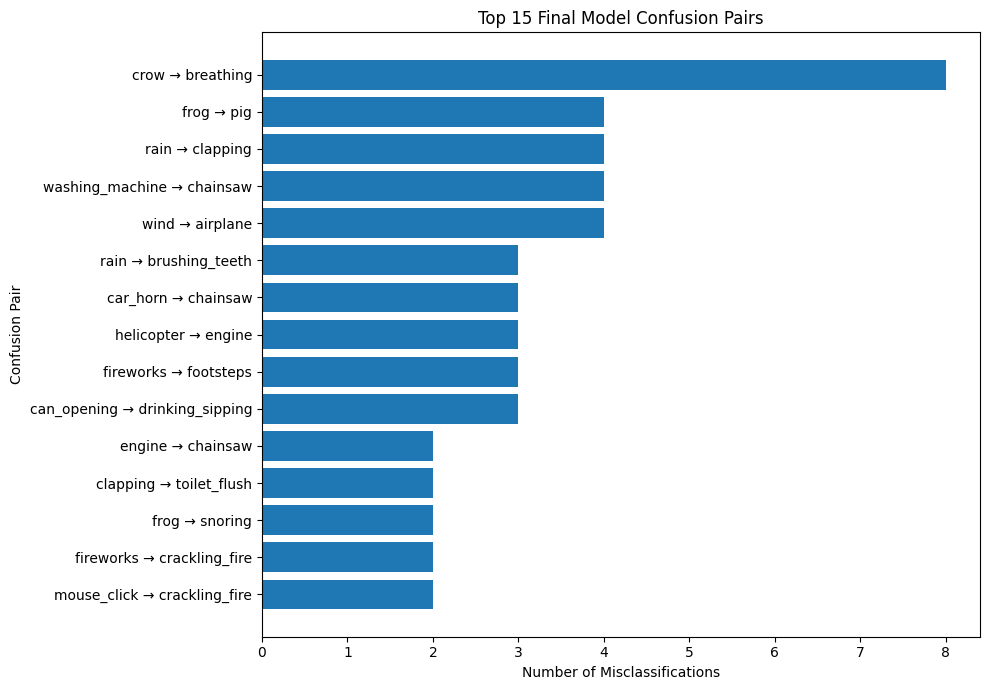

In [165]:
# ============================================================
# TOP 15 FINAL MODEL CONFUSION PAIRS
# ============================================================

top_final_confusions = (
    final_confusion_pairs_df
    .head(15)
    .copy()
)

top_final_confusions["Pair"] = (
    top_final_confusions["True Class"]
    + " → "
    + top_final_confusions["Predicted Class"]
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_final_confusions["Pair"][::-1],
    top_final_confusions["Count"][::-1]
)

plt.xlabel("Number of Misclassifications")
plt.ylabel("Confusion Pair")
plt.title("Top 15 Final Model Confusion Pairs")

plt.tight_layout()
plt.show()

In [166]:
# ============================================================
# PHASE 15.8 — FINAL SUMMARY
# ============================================================

best_final_class = (
    final_per_class_df
    .iloc[0]
)

worst_final_class = (
    final_per_class_df
    .sort_values("Accuracy (%)", ascending=True)
    .iloc[0]
)

print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(
    f"Test Accuracy : "
    f"{final_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision: "
    f"{final_precision * 100:.2f}%"
)

print(
    f"Macro Recall   : "
    f"{final_recall * 100:.2f}%"
)

print(
    f"Macro F1 Score : "
    f"{final_f1 * 100:.2f}%"
)

print()

print(
    f"Best Class     : "
    f"{best_final_class['Class']} "
    f"({best_final_class['Accuracy (%)']:.2f}%)"
)

print(
    f"Most Difficult : "
    f"{worst_final_class['Class']} "
    f"({worst_final_class['Accuracy (%)']:.2f}%)"
)

print("=" * 60)

FINAL MODEL SUMMARY
Test Accuracy : 59.50%
Macro Precision: 67.42%
Macro Recall   : 59.50%
Macro F1 Score : 57.24%

Best Class     : chainsaw (100.00%)
Most Difficult : crow (0.00%)
